In [ ]:
import os
import numpy as np
import sys
sys.path.append('C:/Nacho/Universidad/Prácticas Raman/LIBS_QUANTIFICATION_INTA')
#sys.path.append('C:/Users/elsam/Documents/GitHub/LIBS_QUANTIFICATION_INTA')
from LIBS_quantification_toolbox import * 
import numpy as np

def lvl0_to_lvl1(carpeta):
    """
    Recorre ../Spectra/<carpeta>/Level0/MX/PY, procesa los 5 shots de cada spot y
    guarda en ../Spectra/<carpeta>/Level1 los resultados:
      - LVL1_MX_PY.txt  (dos columnas: wavelength y intensity)
      - LVL1_MX_PY.png  (gráfico del espectro concatenado)
    guarda en ../Spectra/<carpeta>/Level2 los resultados:
      - LVL2_MX_PY.txt  (dos columnas: wavelength y intensity)
      - LVL2_MX_PY.png  (gráfico del espectro procesado)

    Parámetros
    ----------
    carpeta : str
        Nombre de la subcarpeta bajo ../Spectra/ que contiene Level0.

    Salida
    ------
    Ninguna. Se crean archivos en ../Spectra/<carpeta>/Level1/
    """
    base_dir  = os.path.join('..', 'Spectra', carpeta)
    lvl0_dir  = os.path.join(base_dir, 'Level0')
    lvl1_dir  = os.path.join(base_dir, 'Level1')
    lvl2_dir  = os.path.join(base_dir, 'Level2')
    os.makedirs(lvl1_dir, exist_ok=True)
    os.makedirs(lvl2_dir, exist_ok=True)
   # Itera sobre cada carpeta MX
    for mx in sorted(os.listdir(lvl0_dir)):
        mx_path = os.path.join(lvl0_dir, mx)
        if not os.path.isdir(mx_path):
            continue

        # Dentro de MX, cada subcarpeta PY
        for py in sorted(os.listdir(mx_path)):
            py_path = os.path.join(mx_path, py)
            if not os.path.isdir(py_path):
                continue

            # nombre_base = "MX_PY"
            nombre_base = f"{mx}_{py}"
            # Llama a la rutina que carga y promedia los 5 shots
            wls, espectros, nombres = cargar_espectros_5shotspromV2_0(
                carpeta=os.path.join(carpeta, 'Level0', mx, py),
                nombre_base=nombre_base)
            if espectros is None:
                print(f"[WARN] No valid shots for {mx}/{py}, skipping.")
                continue
            
            #LVL 1
            # 1) Concatenar segmentos para generar espectro completo
            full_wl  = np.concatenate(wls)
            full_sp  = np.concatenate(espectros)

            # 2) Guardar TXT de dos columnas: wavelength, intensity
            out_txt_lvl2 = os.path.join(lvl1_dir, f"LVL1_{nombre_base}.txt")
            data_lvl1 = np.column_stack((full_wl,full_sp))
            guardar_resultados_csv(out_txt_lvl2, data_lvl1.tolist())

            # 3) Graficar y guardar PNG
            fig, ax = plot_spectra(wls,espectros,titulo=f"LVL1 {mx} {py}",nombres = nombres,
                xlabel="Wavelength (nm)",ylabel="Intensity (counts)",figsize=(10,6))
            out_png = os.path.join(lvl1_dir, f"LVL1_{nombre_base}.png")
            fig.savefig(out_png)
            ax.clear()
            print(f"[OK] Saved Level1_{nombre_base} to {lvl1_dir}")

            #LVL 2
            #1) Aplicar el preprocesado
            wls_norm, espectros_norm = apply_preprocessing(espectros,wls)

            # 2) Guardar TXT de dos columnas: wavelength, intensity
            out_txt_lvl1 = os.path.join(lvl2_dir, f"LVL2_{nombre_base}.txt")
            data_lvl2 = np.column_stack((wls_norm,espectros_norm))
            guardar_resultados_csv(out_txt_lvl1, data_lvl2.tolist())

            # 3) Graficar y guardar PNG
            fig, ax = plot_spectra(wls_norm,espectros_norm,titulo=f"LVL2 {mx} {py}",
                xlabel="Wavelength (nm)",ylabel="Intensity (norm)",figsize=(10,6))
            out_png = os.path.join(lvl2_dir, f"LVL2_{nombre_base}.png")
            fig.savefig(out_png)
            ax.clear()
            print(f"[OK] Saved Level2_{nombre_base} to {lvl2_dir}")

M1_P1: utilizando 4 de 4 shots para el promedio


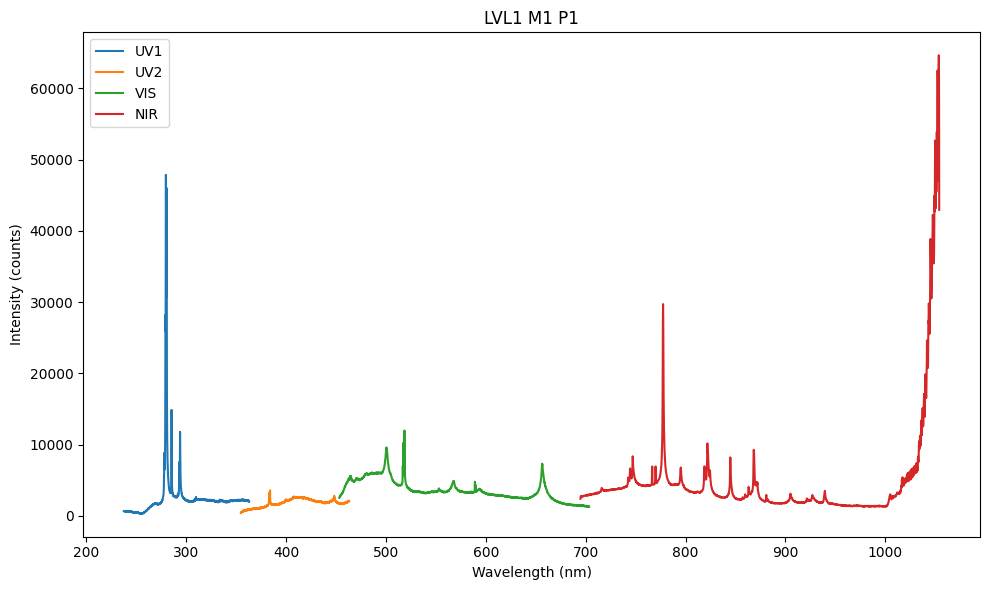

[OK] Saved Level1_M1_P1 to ..\Spectra\FinalSamples\Level1


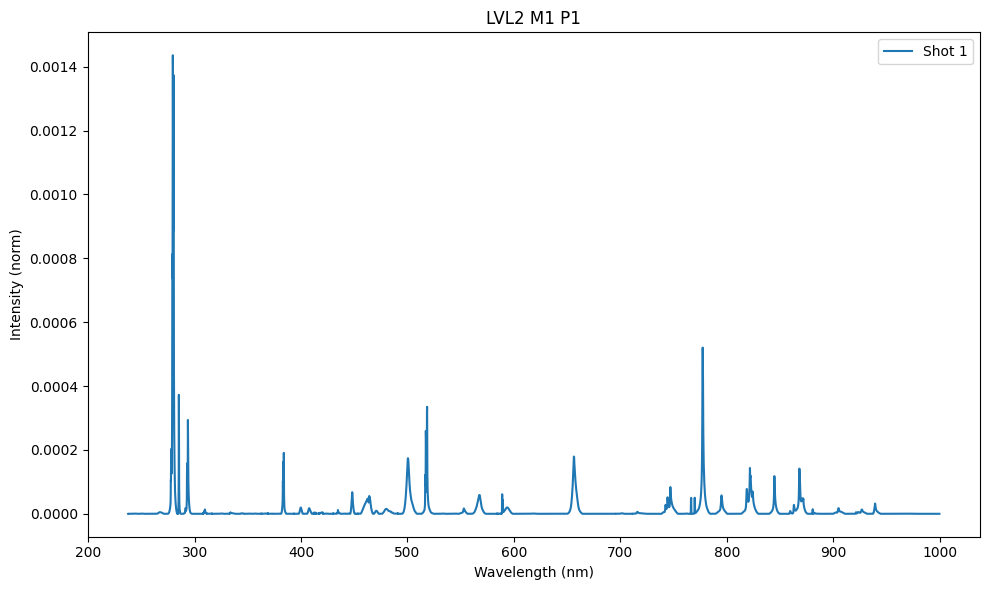

[OK] Saved Level2_M1_P1 to ..\Spectra\FinalSamples\Level2
M1_P2: utilizando 4 de 4 shots para el promedio


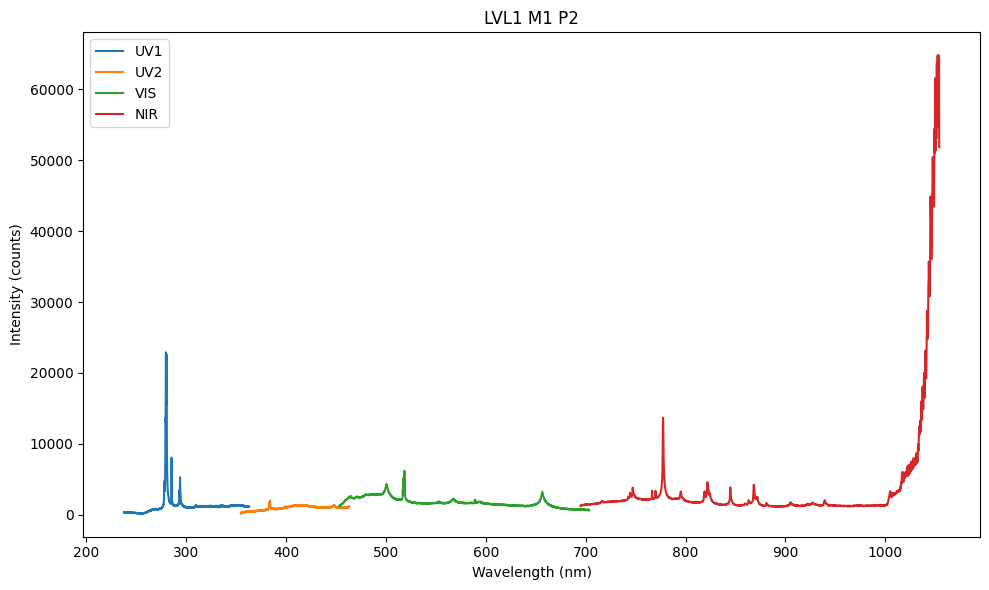

[OK] Saved Level1_M1_P2 to ..\Spectra\FinalSamples\Level1


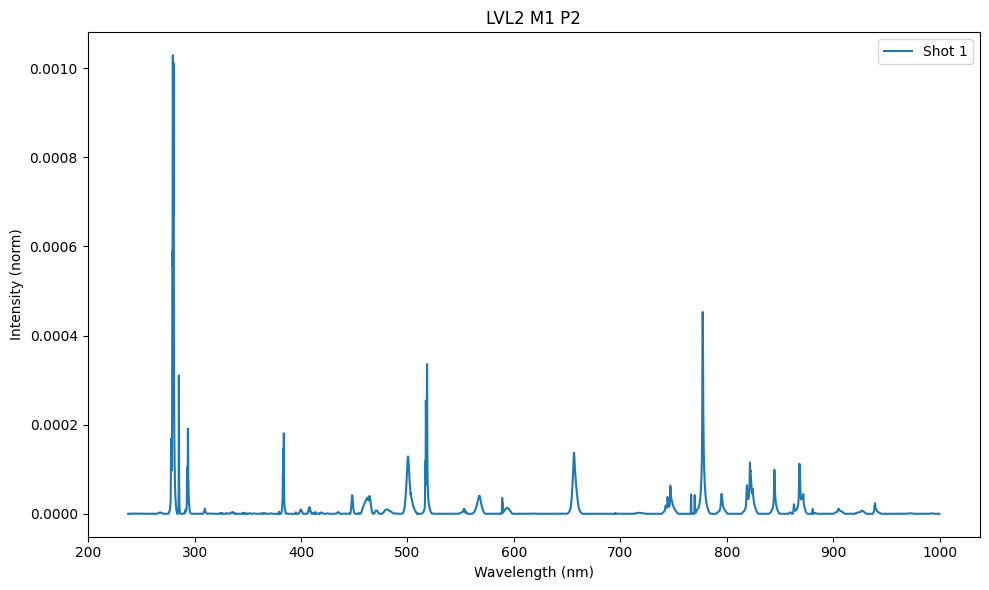

[OK] Saved Level2_M1_P2 to ..\Spectra\FinalSamples\Level2
M1_P3: utilizando 4 de 4 shots para el promedio


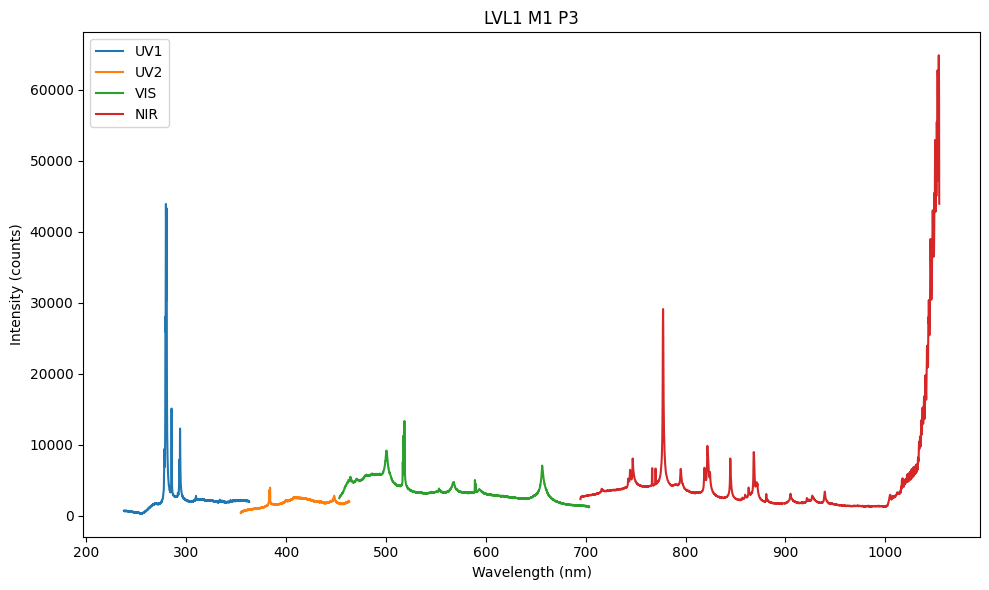

[OK] Saved Level1_M1_P3 to ..\Spectra\FinalSamples\Level1


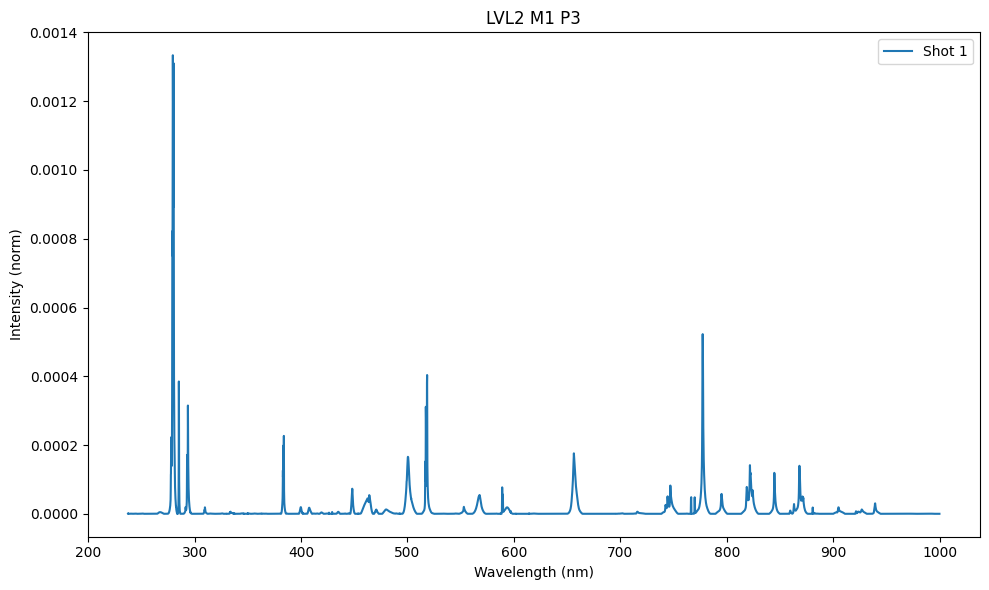

[OK] Saved Level2_M1_P3 to ..\Spectra\FinalSamples\Level2
M10_P1: utilizando 1 de 4 shots para el promedio


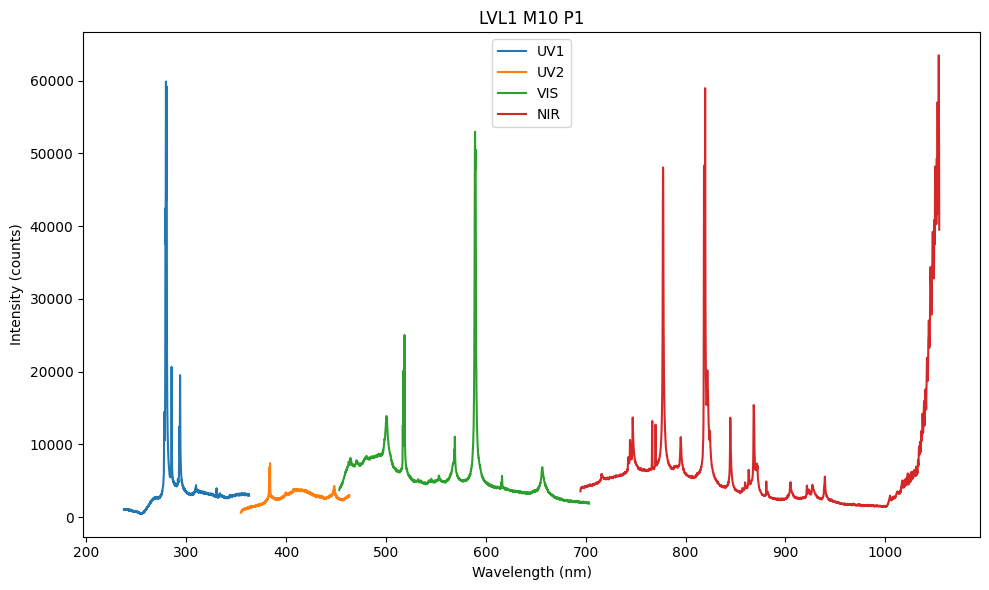

[OK] Saved Level1_M10_P1 to ..\Spectra\FinalSamples\Level1


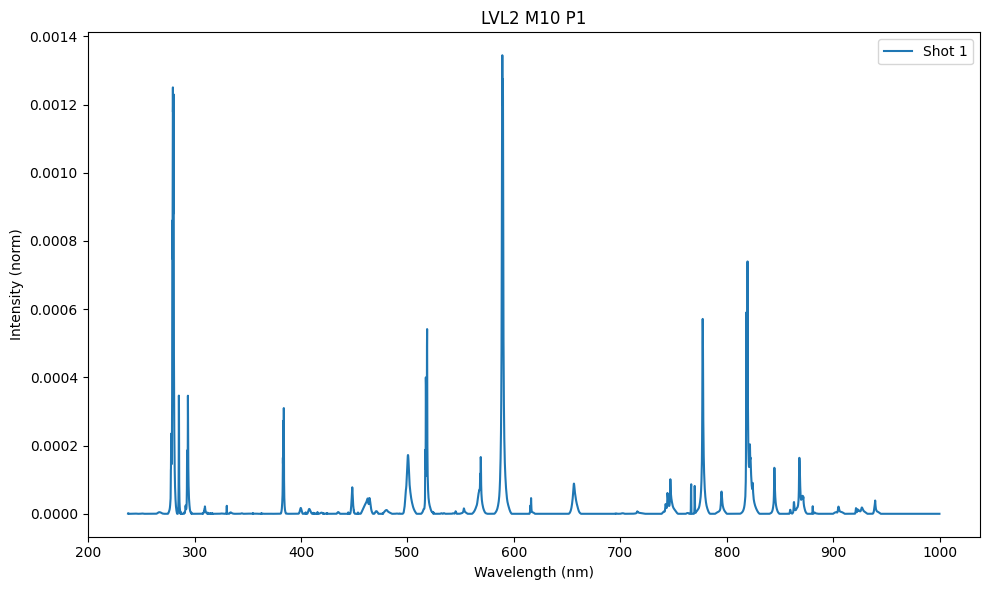

[OK] Saved Level2_M10_P1 to ..\Spectra\FinalSamples\Level2
M10_P2: utilizando 3 de 4 shots para el promedio


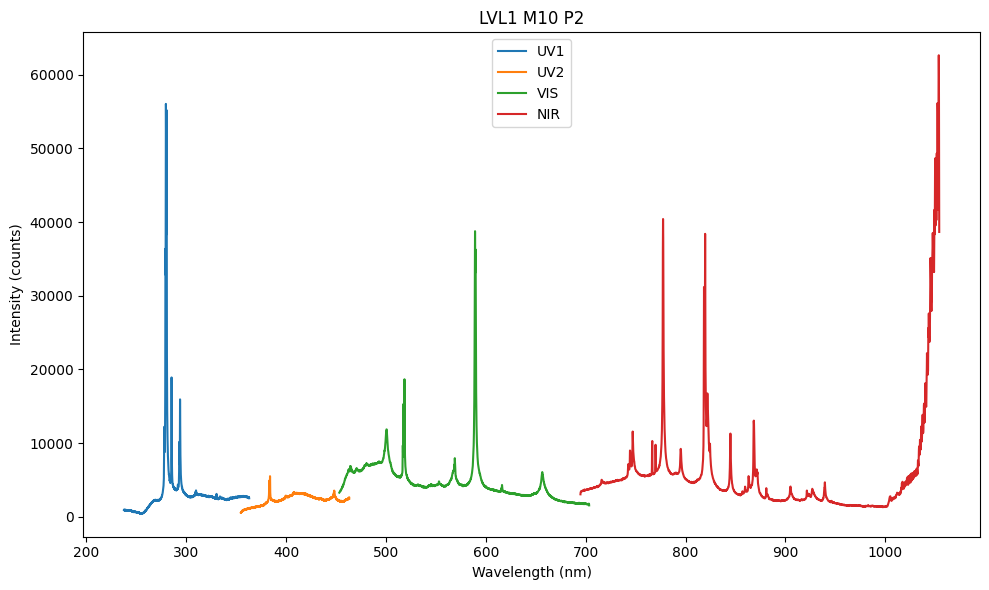

[OK] Saved Level1_M10_P2 to ..\Spectra\FinalSamples\Level1


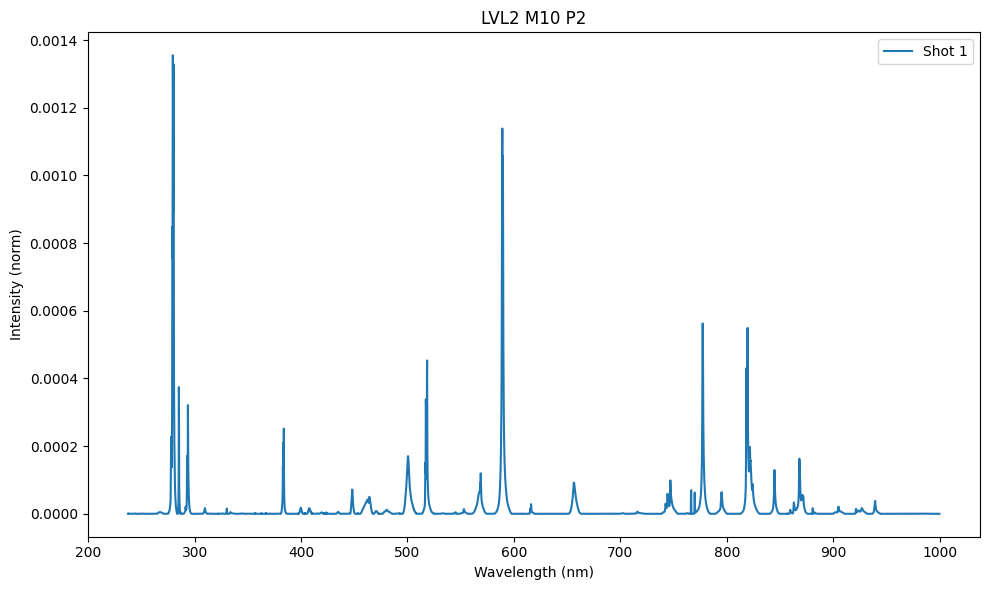

[OK] Saved Level2_M10_P2 to ..\Spectra\FinalSamples\Level2
M10_P3: utilizando 2 de 4 shots para el promedio


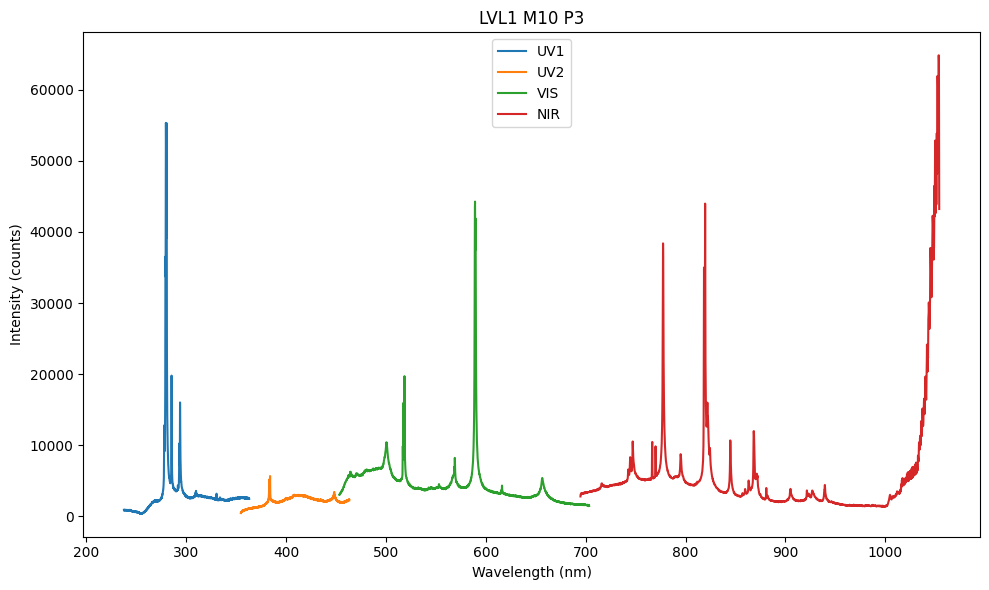

[OK] Saved Level1_M10_P3 to ..\Spectra\FinalSamples\Level1


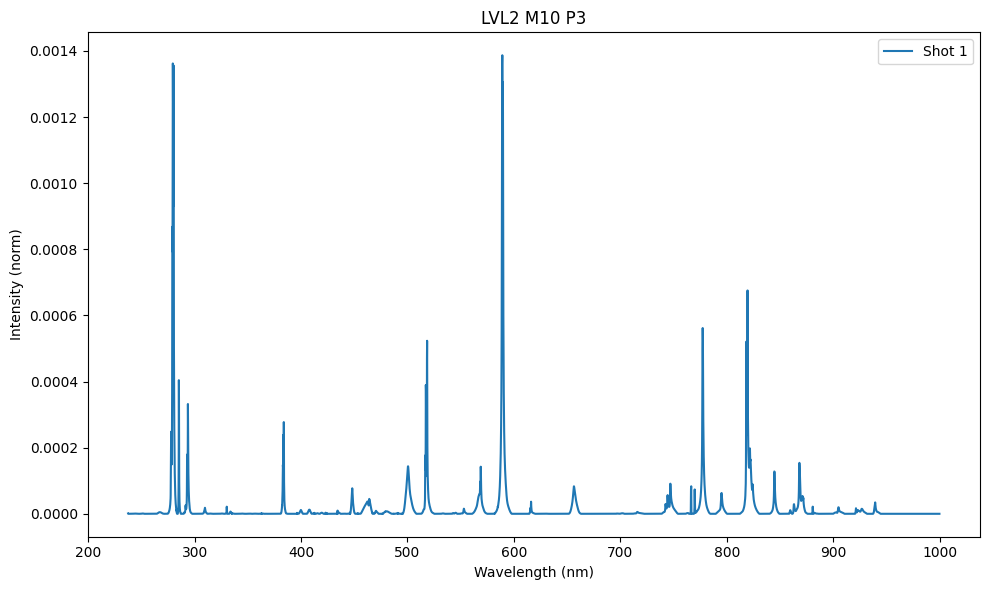

[OK] Saved Level2_M10_P3 to ..\Spectra\FinalSamples\Level2
M11_P1: utilizando 2 de 4 shots para el promedio


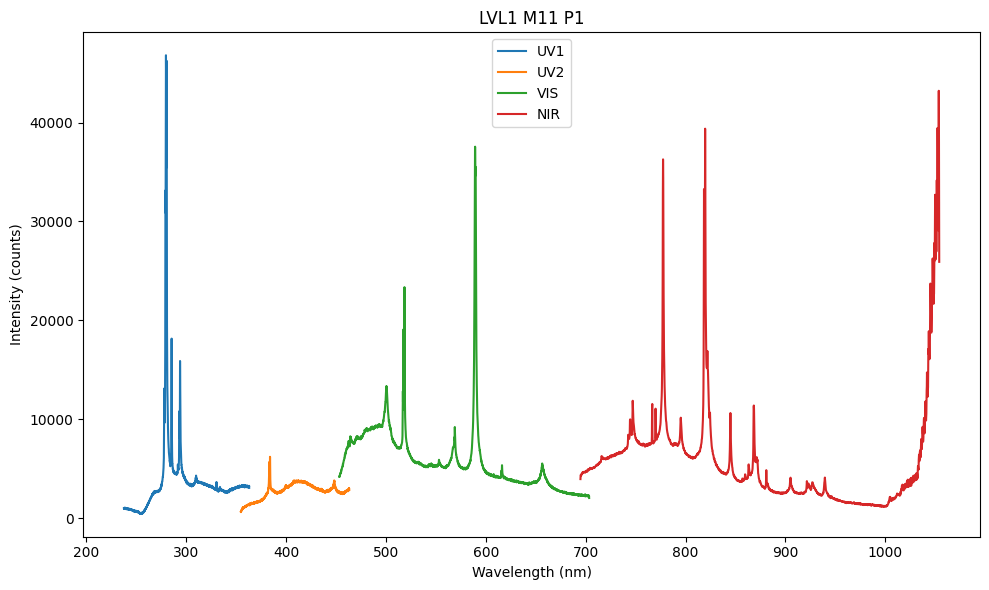

[OK] Saved Level1_M11_P1 to ..\Spectra\FinalSamples\Level1


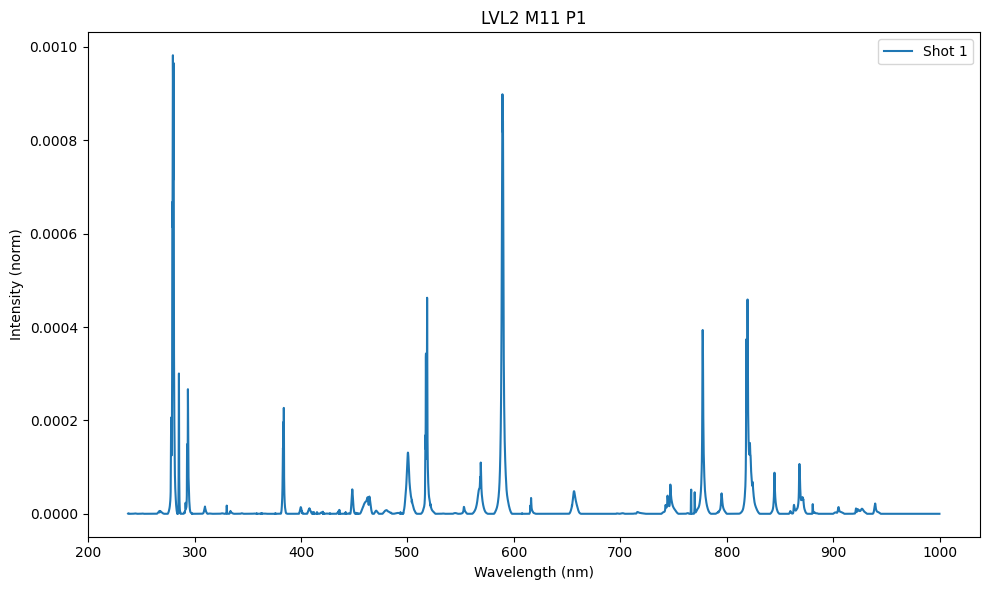

[OK] Saved Level2_M11_P1 to ..\Spectra\FinalSamples\Level2
M11_P2: utilizando 4 de 4 shots para el promedio


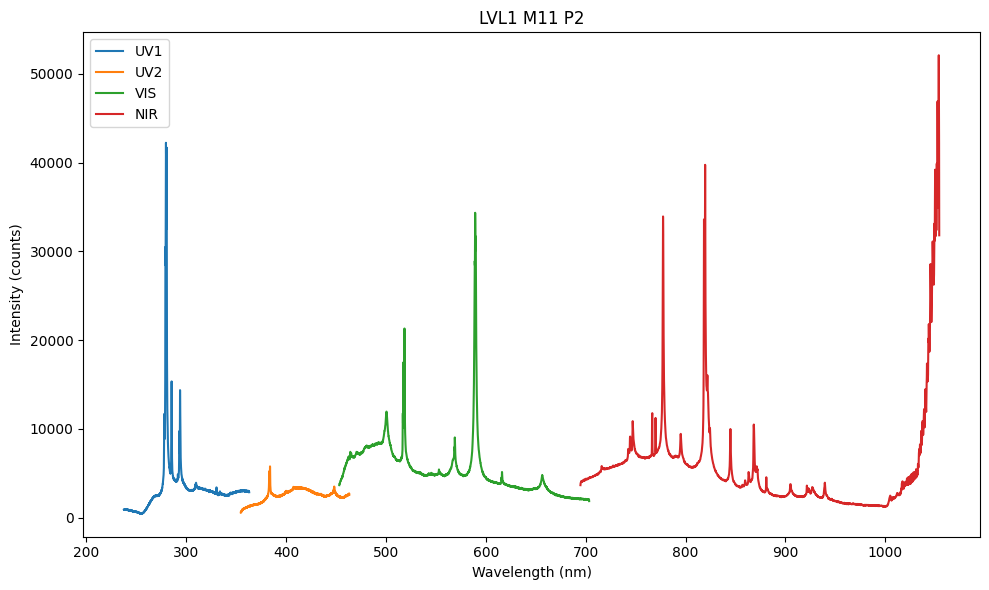

[OK] Saved Level1_M11_P2 to ..\Spectra\FinalSamples\Level1


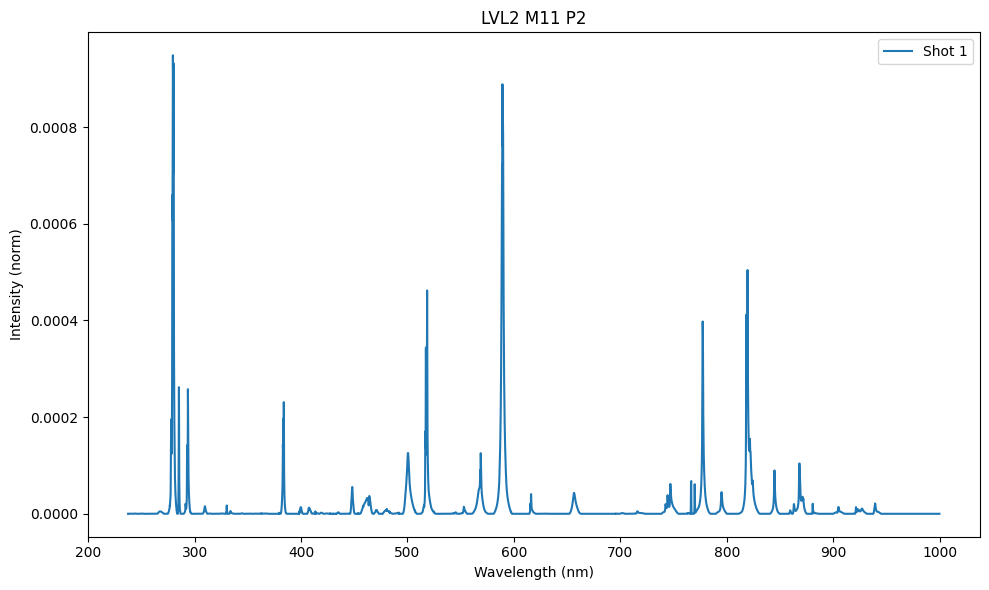

[OK] Saved Level2_M11_P2 to ..\Spectra\FinalSamples\Level2
M11_P3: utilizando 3 de 4 shots para el promedio


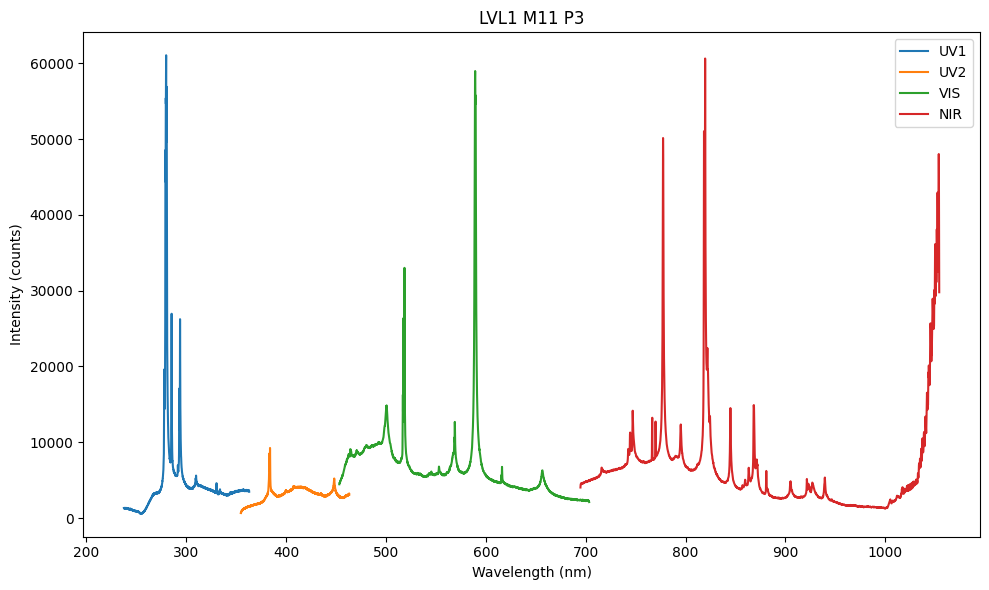

[OK] Saved Level1_M11_P3 to ..\Spectra\FinalSamples\Level1


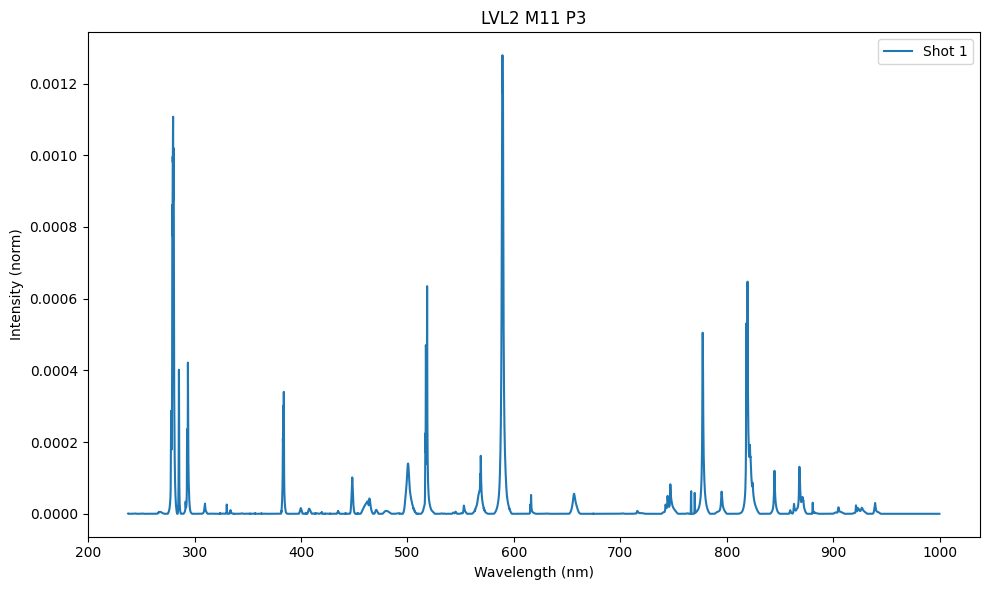

[OK] Saved Level2_M11_P3 to ..\Spectra\FinalSamples\Level2
M12_P1: utilizando 4 de 4 shots para el promedio


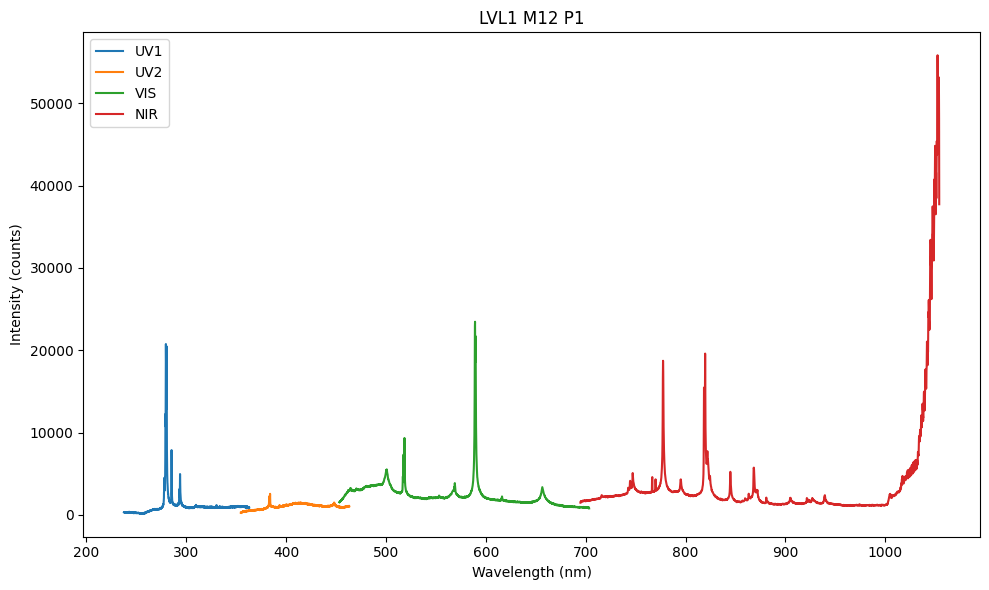

[OK] Saved Level1_M12_P1 to ..\Spectra\FinalSamples\Level1


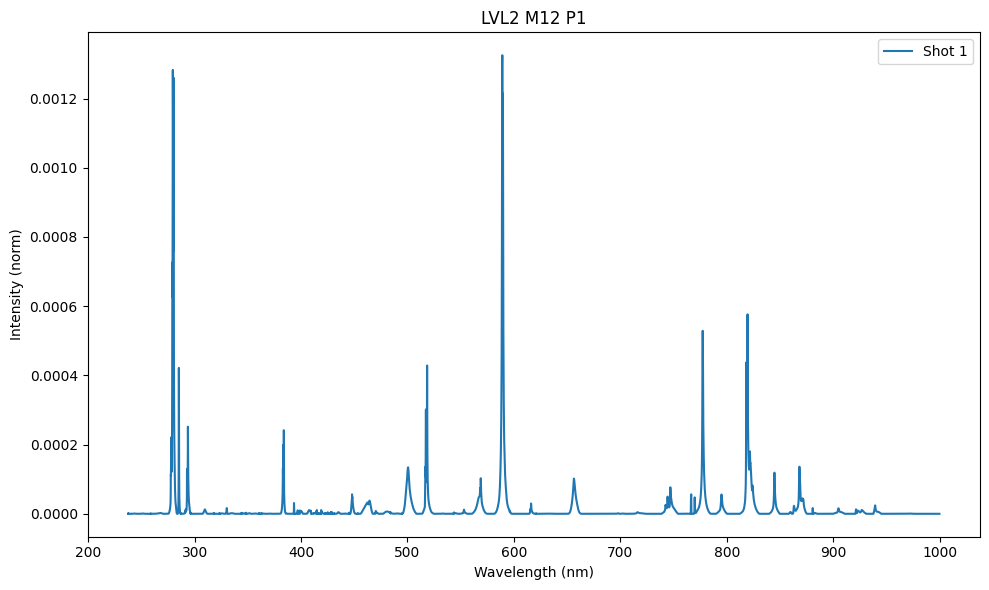

[OK] Saved Level2_M12_P1 to ..\Spectra\FinalSamples\Level2
M12_P2: utilizando 4 de 4 shots para el promedio


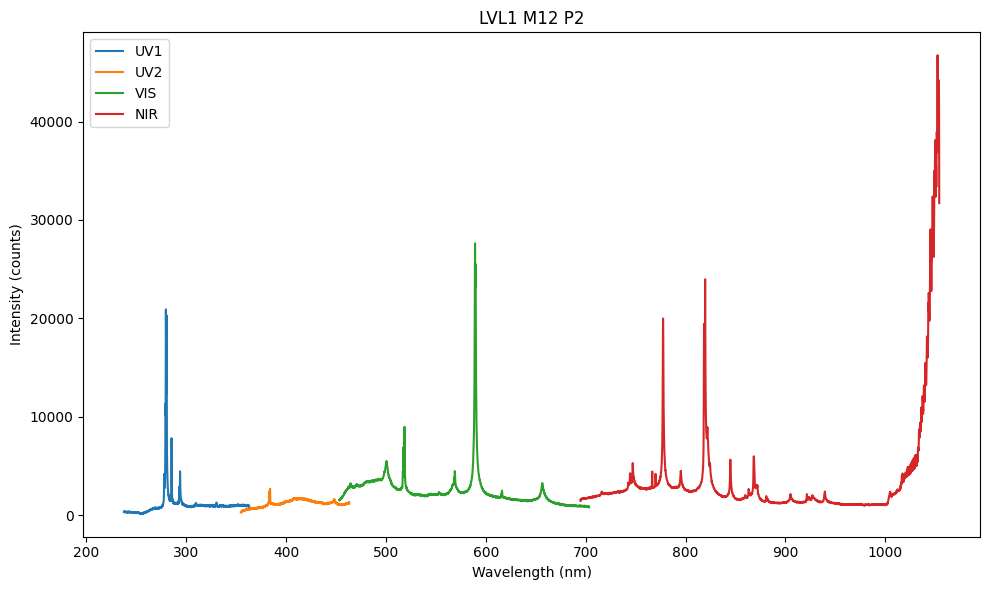

[OK] Saved Level1_M12_P2 to ..\Spectra\FinalSamples\Level1


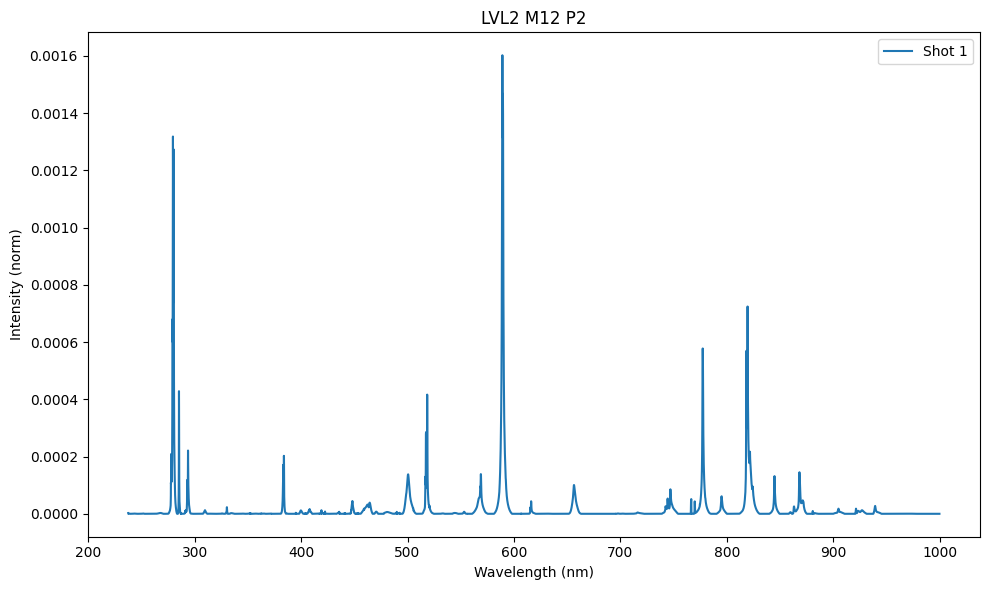

[OK] Saved Level2_M12_P2 to ..\Spectra\FinalSamples\Level2
M12_P3: utilizando 4 de 4 shots para el promedio


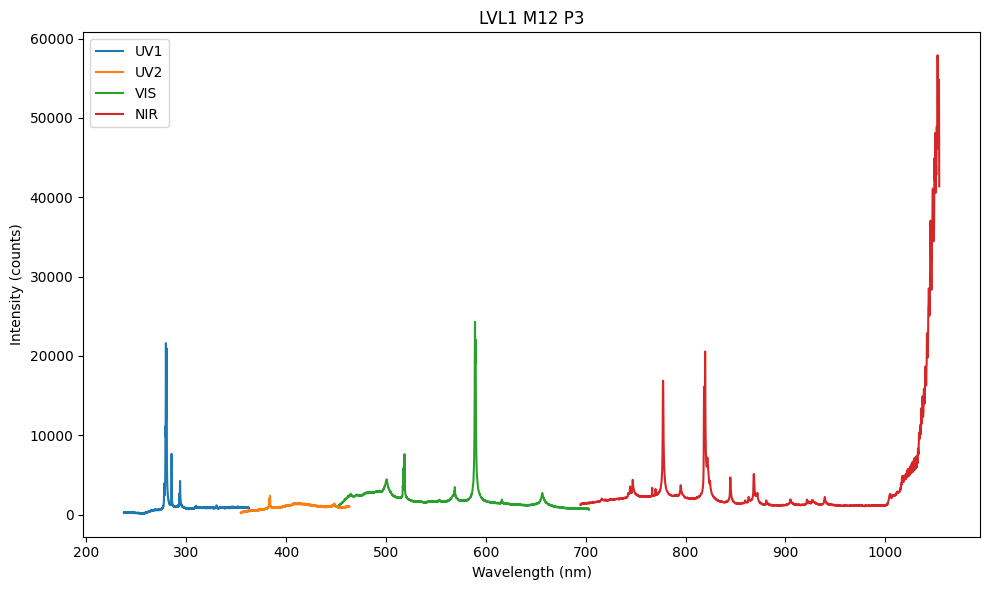

[OK] Saved Level1_M12_P3 to ..\Spectra\FinalSamples\Level1


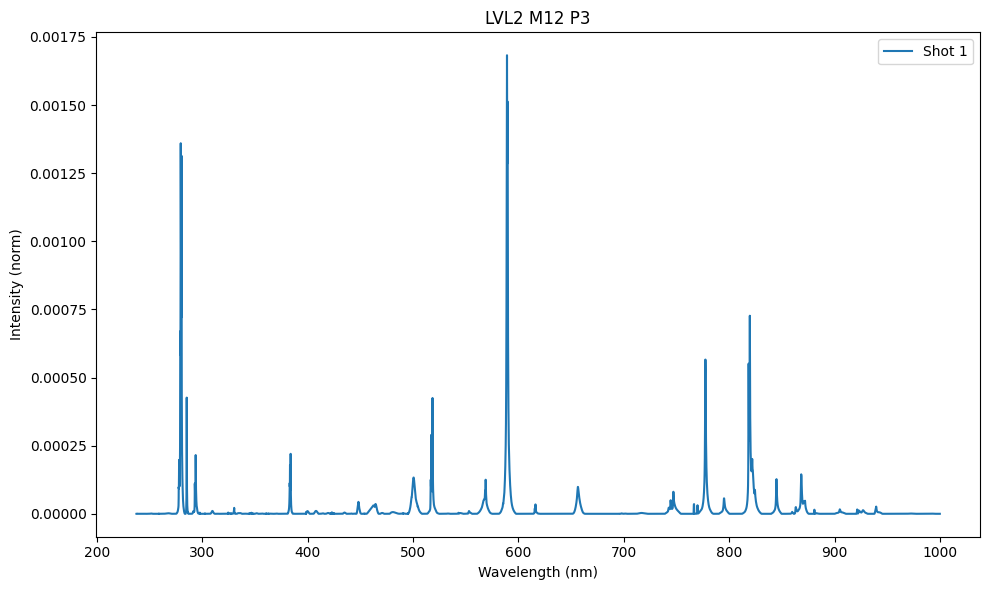

[OK] Saved Level2_M12_P3 to ..\Spectra\FinalSamples\Level2
M13_P1: todos los espectros saturan o están fuera de rango
[WARN] No valid shots for M13/P1, skipping.
M13_P2: utilizando 1 de 4 shots para el promedio


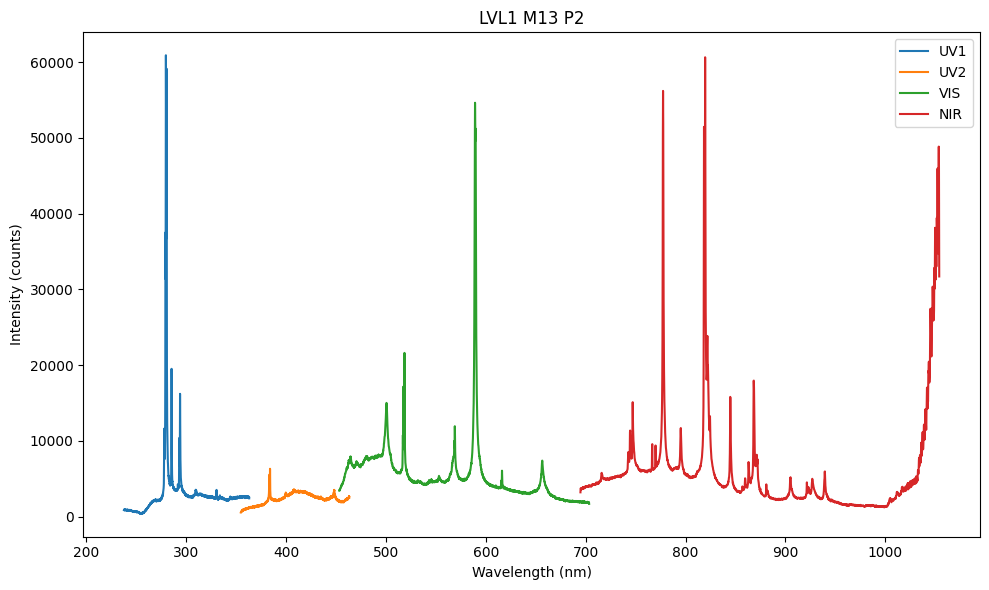

[OK] Saved Level1_M13_P2 to ..\Spectra\FinalSamples\Level1


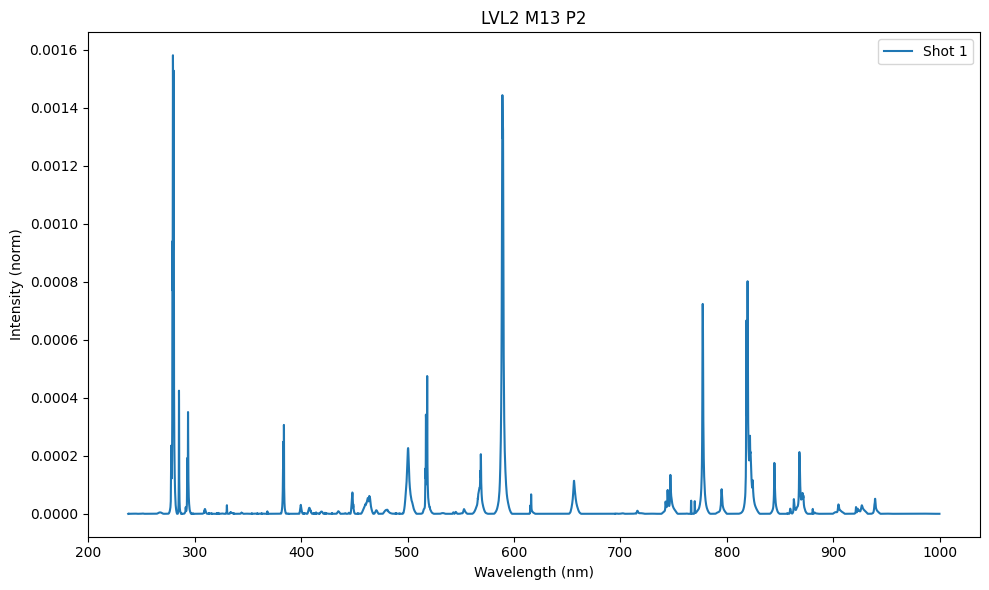

[OK] Saved Level2_M13_P2 to ..\Spectra\FinalSamples\Level2
M13_P3: utilizando 2 de 4 shots para el promedio


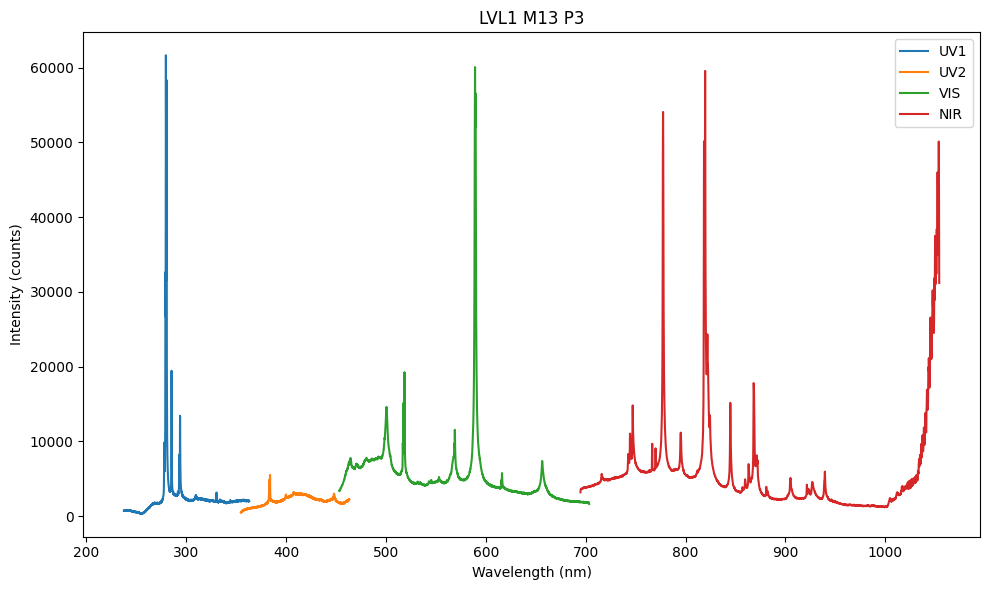

[OK] Saved Level1_M13_P3 to ..\Spectra\FinalSamples\Level1


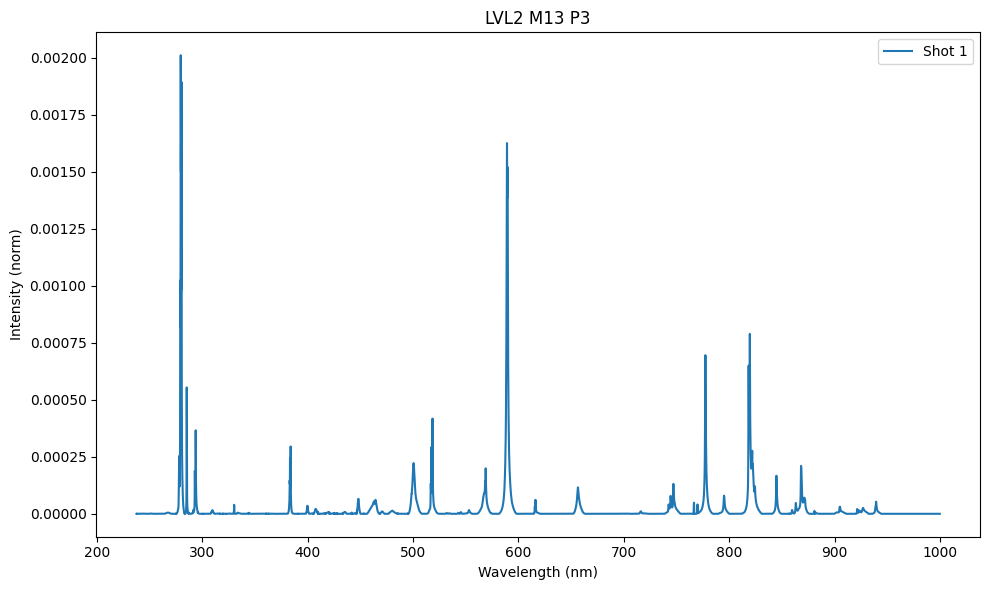

[OK] Saved Level2_M13_P3 to ..\Spectra\FinalSamples\Level2
M14_P1: utilizando 2 de 4 shots para el promedio


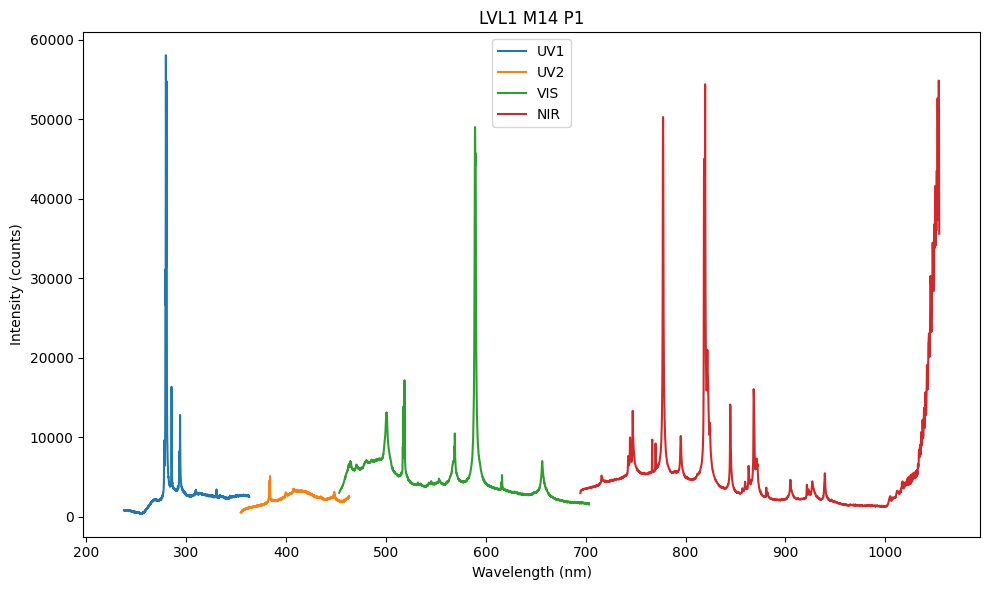

[OK] Saved Level1_M14_P1 to ..\Spectra\FinalSamples\Level1


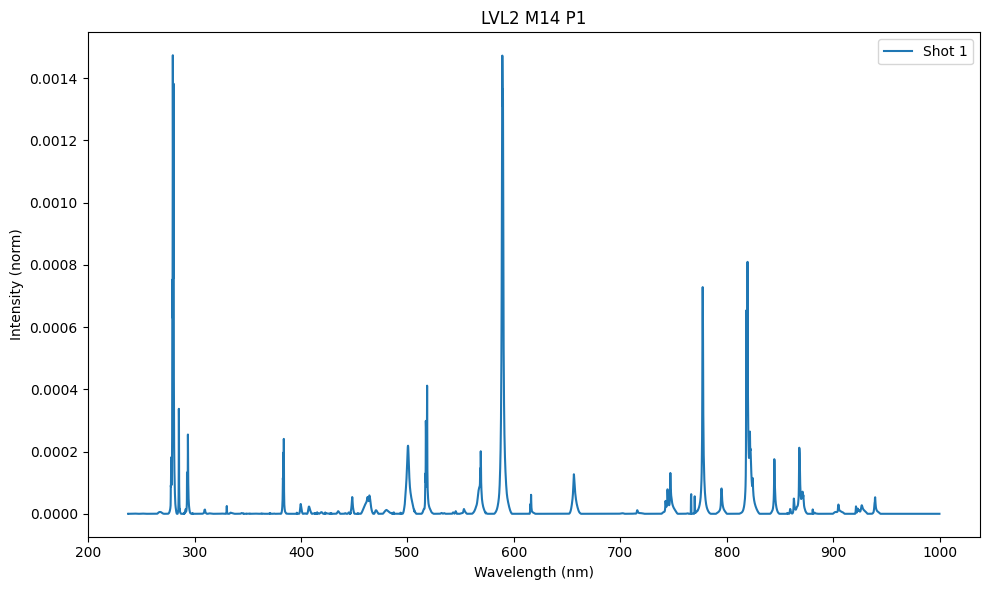

[OK] Saved Level2_M14_P1 to ..\Spectra\FinalSamples\Level2
M14_P2: utilizando 3 de 4 shots para el promedio


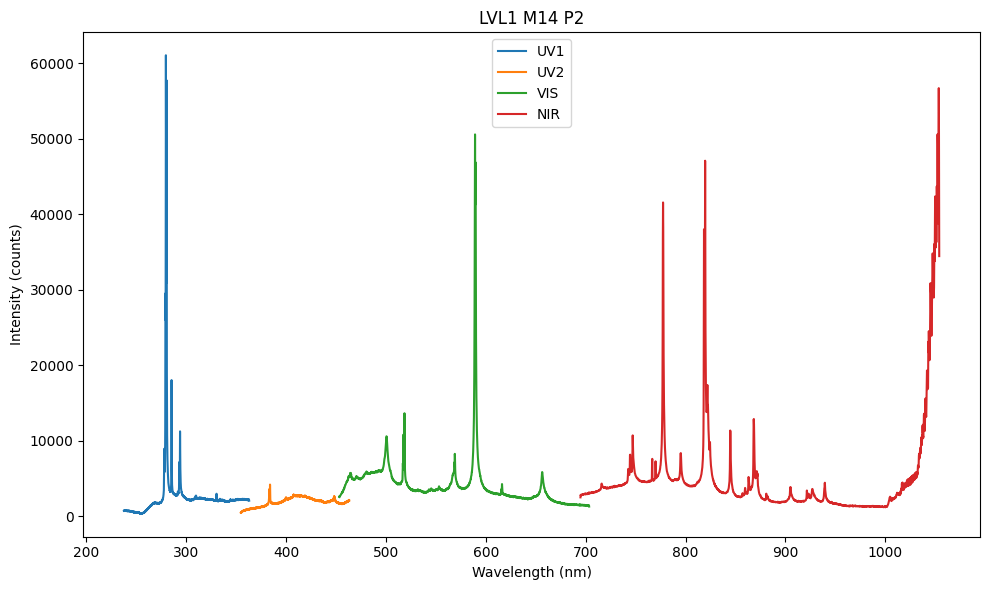

[OK] Saved Level1_M14_P2 to ..\Spectra\FinalSamples\Level1


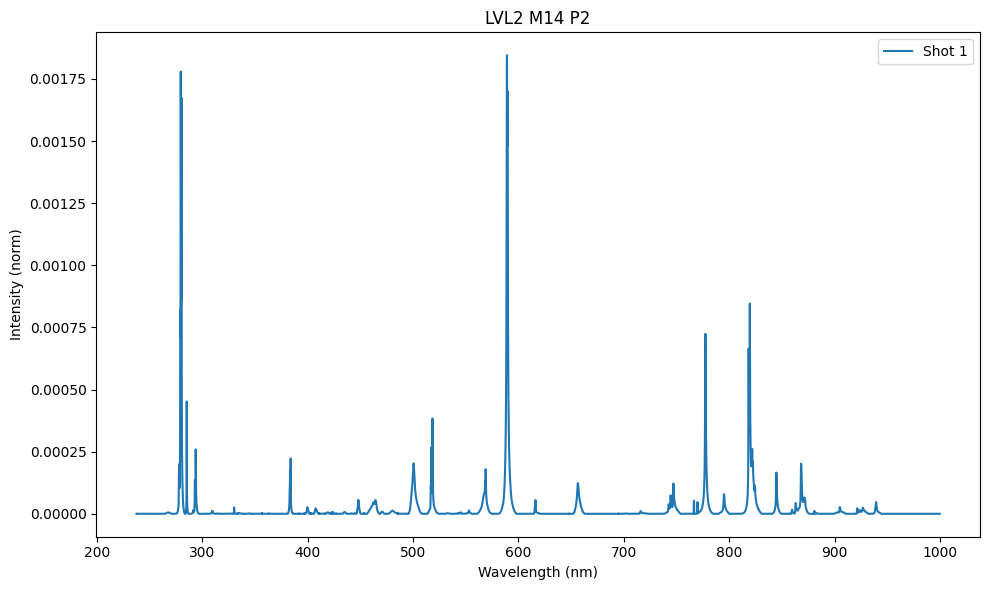

[OK] Saved Level2_M14_P2 to ..\Spectra\FinalSamples\Level2
M14_P3: utilizando 2 de 4 shots para el promedio


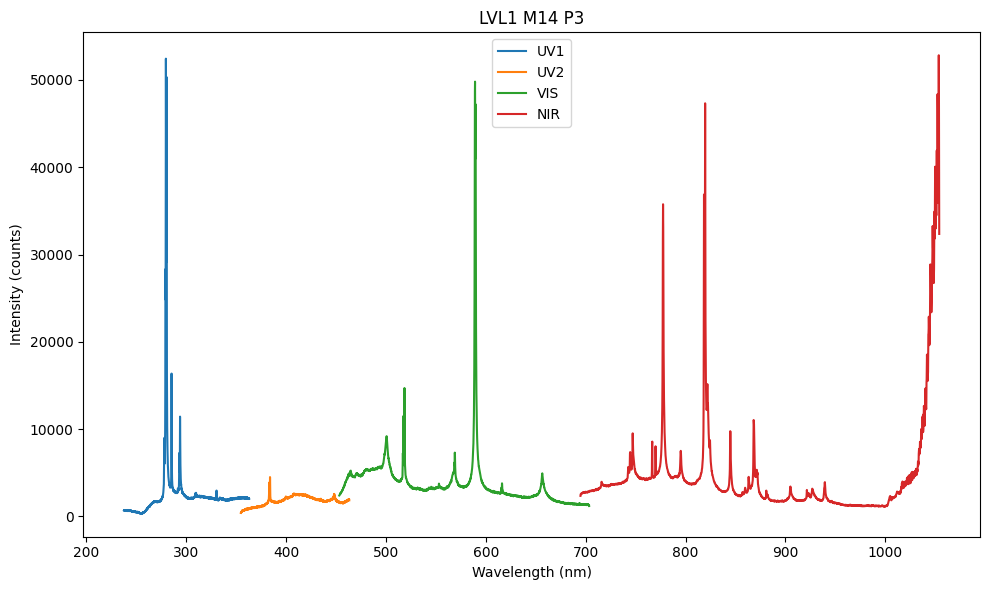

[OK] Saved Level1_M14_P3 to ..\Spectra\FinalSamples\Level1


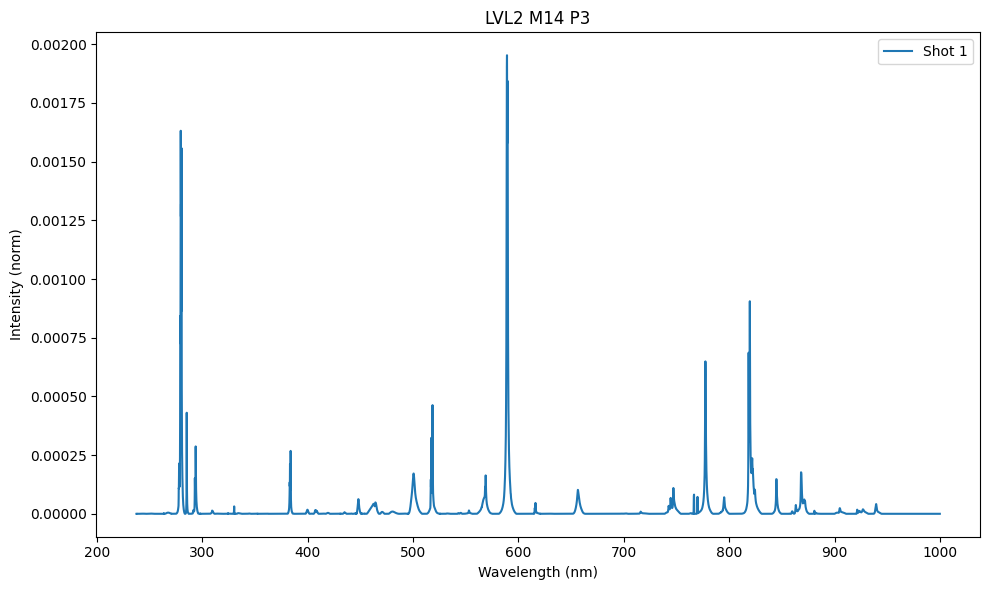

[OK] Saved Level2_M14_P3 to ..\Spectra\FinalSamples\Level2
M15_P1: todos los espectros saturan o están fuera de rango
[WARN] No valid shots for M15/P1, skipping.
M15_P2: utilizando 3 de 4 shots para el promedio


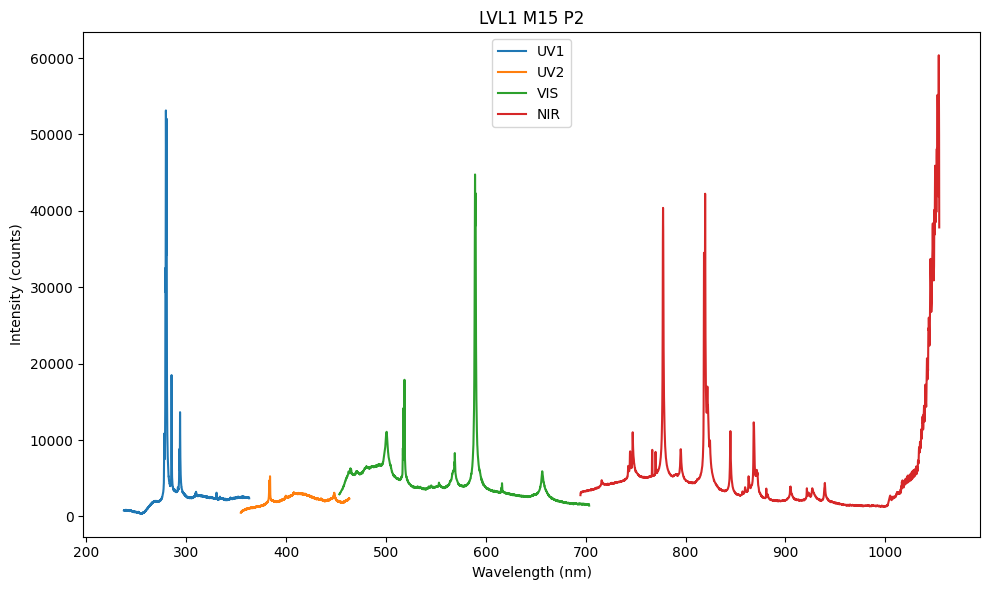

[OK] Saved Level1_M15_P2 to ..\Spectra\FinalSamples\Level1


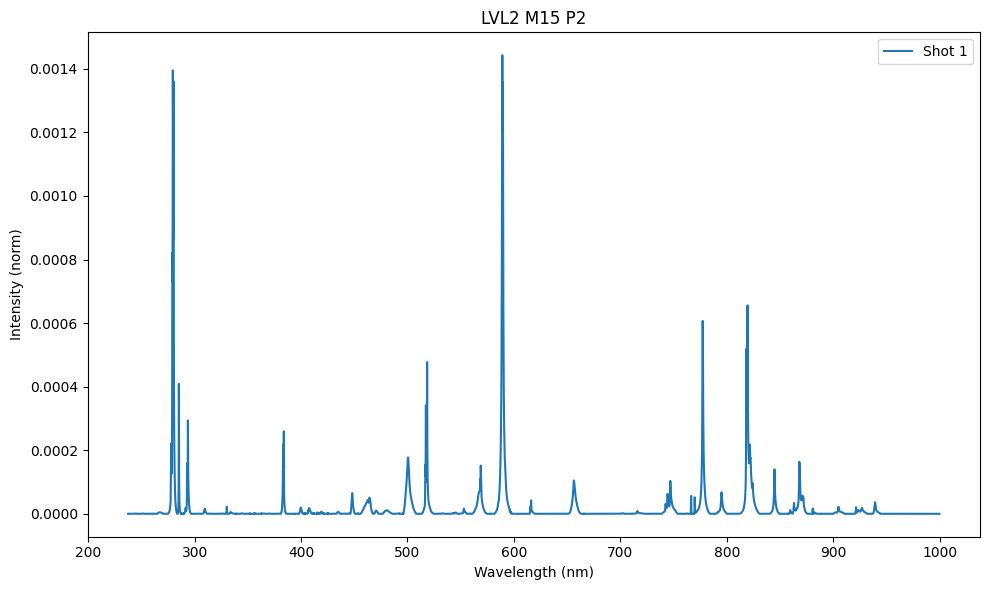

[OK] Saved Level2_M15_P2 to ..\Spectra\FinalSamples\Level2
M15_P3: utilizando 4 de 4 shots para el promedio


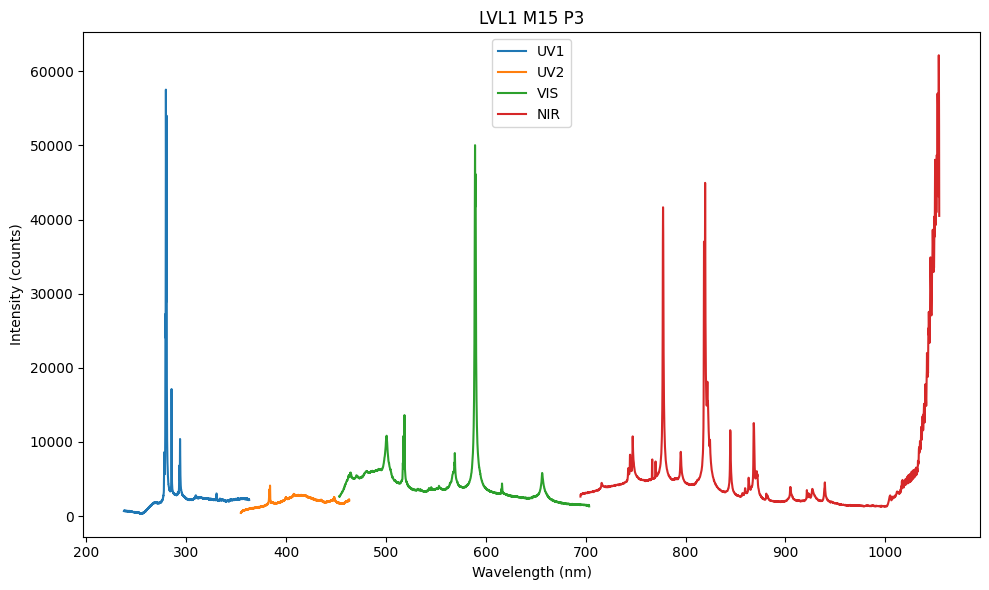

[OK] Saved Level1_M15_P3 to ..\Spectra\FinalSamples\Level1


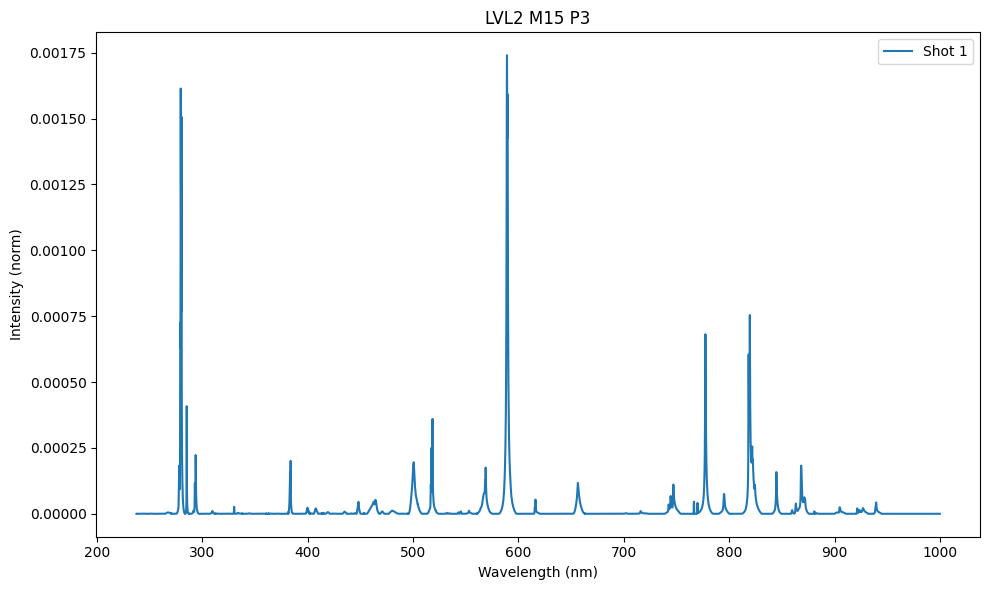

[OK] Saved Level2_M15_P3 to ..\Spectra\FinalSamples\Level2
M16_P1: utilizando 3 de 4 shots para el promedio


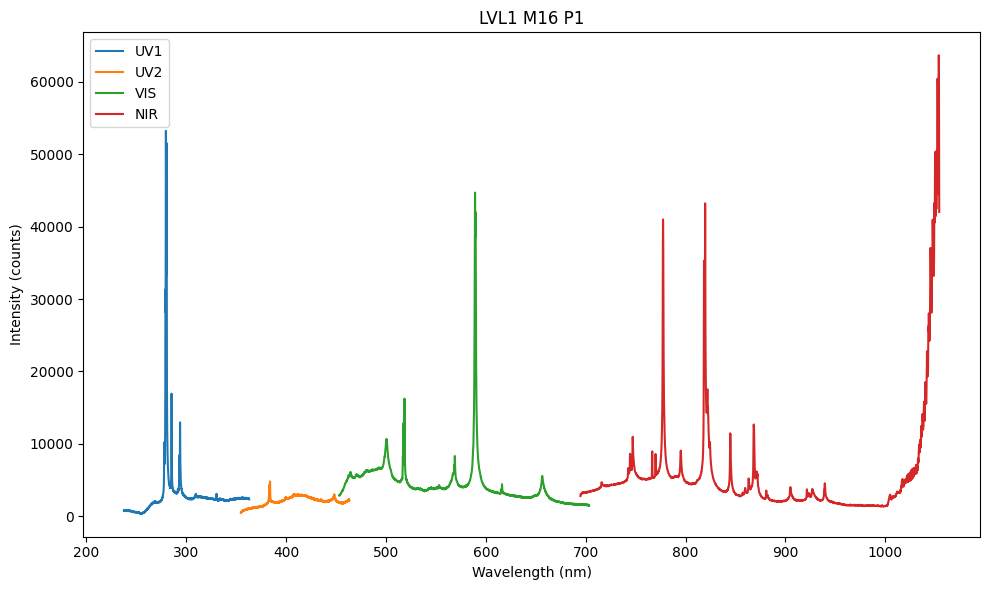

[OK] Saved Level1_M16_P1 to ..\Spectra\FinalSamples\Level1


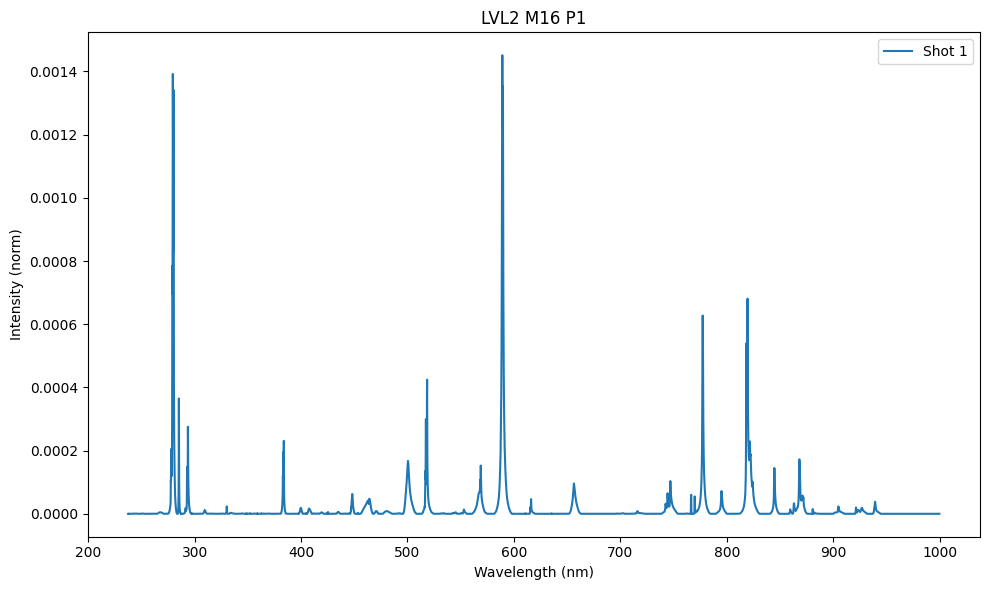

[OK] Saved Level2_M16_P1 to ..\Spectra\FinalSamples\Level2
M16_P2: utilizando 2 de 4 shots para el promedio


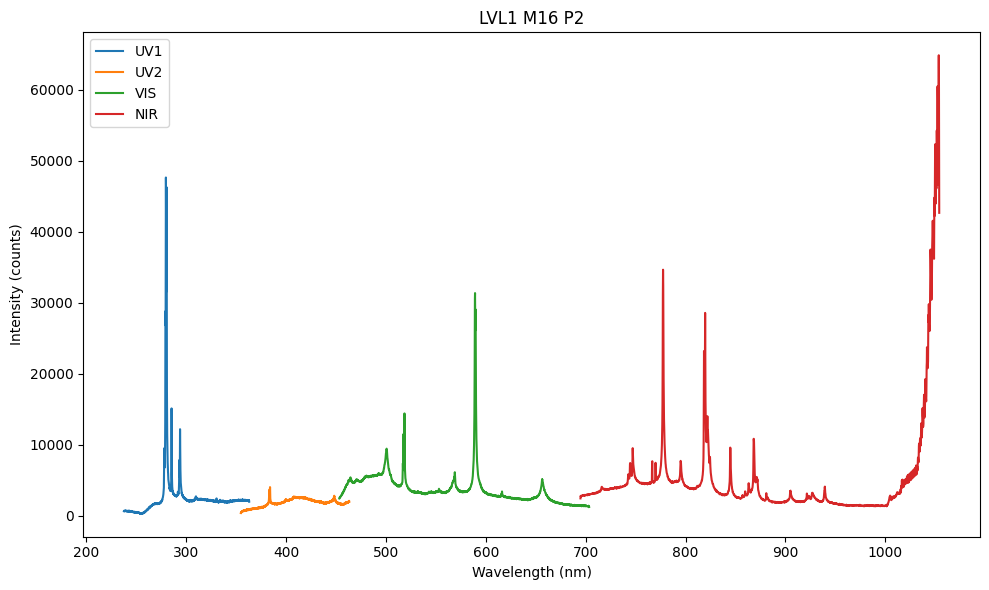

[OK] Saved Level1_M16_P2 to ..\Spectra\FinalSamples\Level1


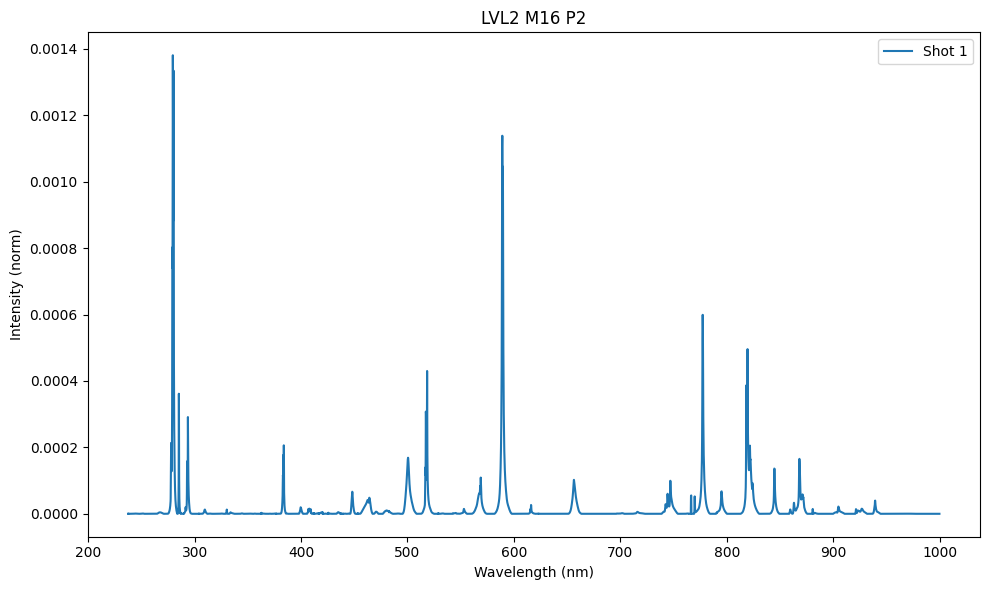

[OK] Saved Level2_M16_P2 to ..\Spectra\FinalSamples\Level2
M16_P3: utilizando 1 de 4 shots para el promedio


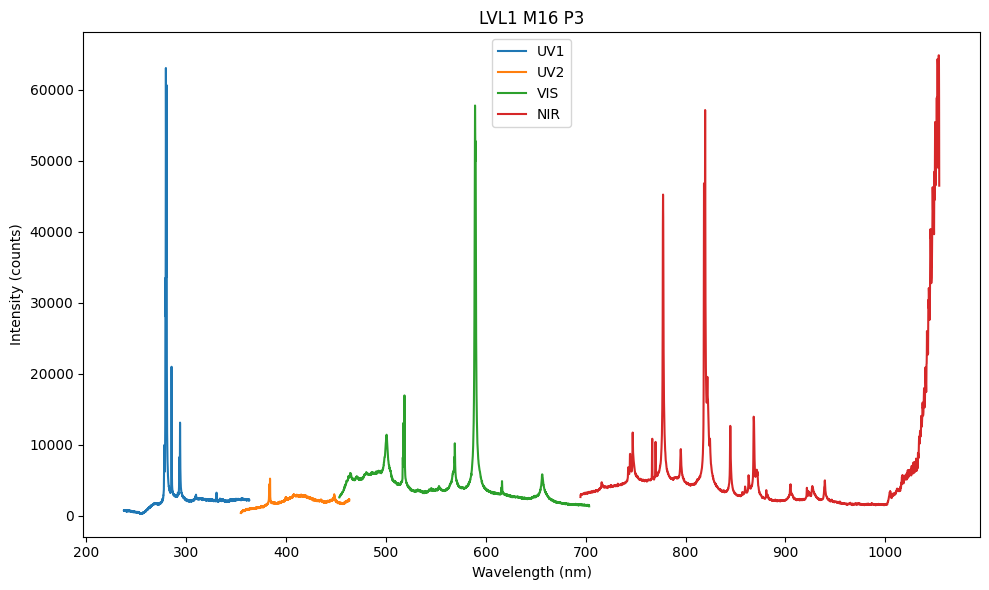

[OK] Saved Level1_M16_P3 to ..\Spectra\FinalSamples\Level1


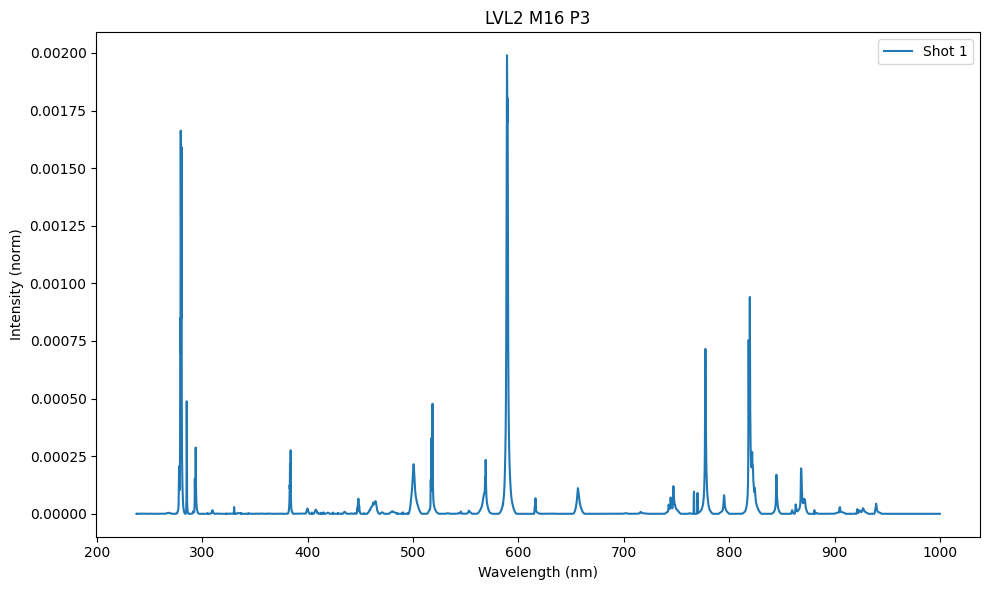

[OK] Saved Level2_M16_P3 to ..\Spectra\FinalSamples\Level2
M17_P1: utilizando 2 de 4 shots para el promedio


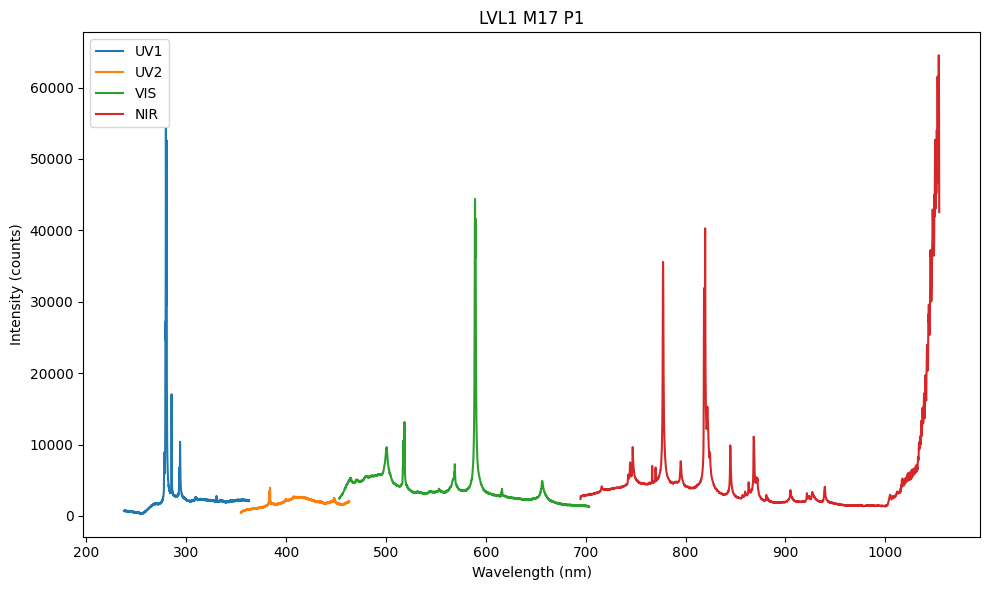

[OK] Saved Level1_M17_P1 to ..\Spectra\FinalSamples\Level1


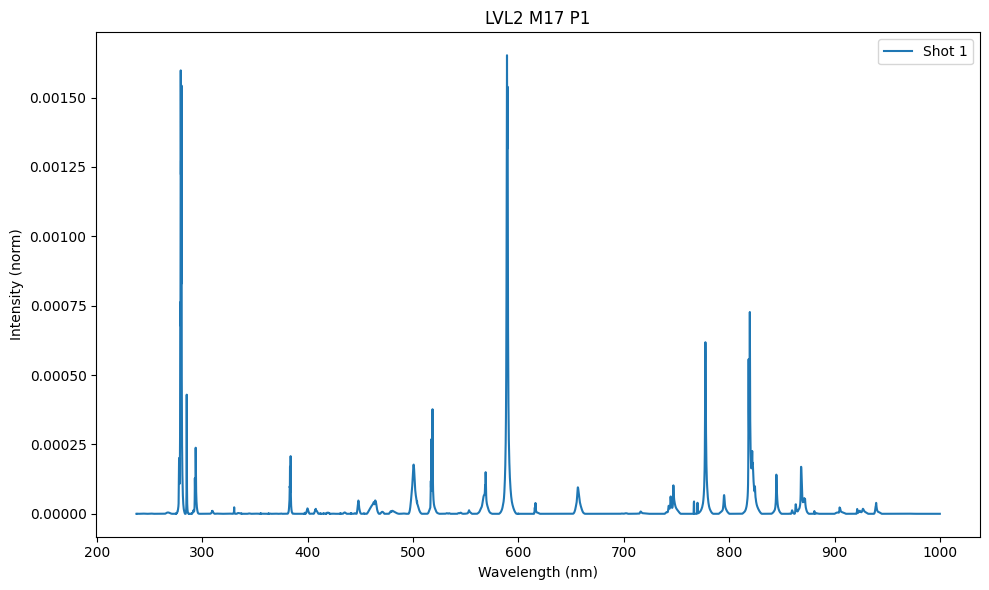

[OK] Saved Level2_M17_P1 to ..\Spectra\FinalSamples\Level2
M17_P2: utilizando 1 de 4 shots para el promedio


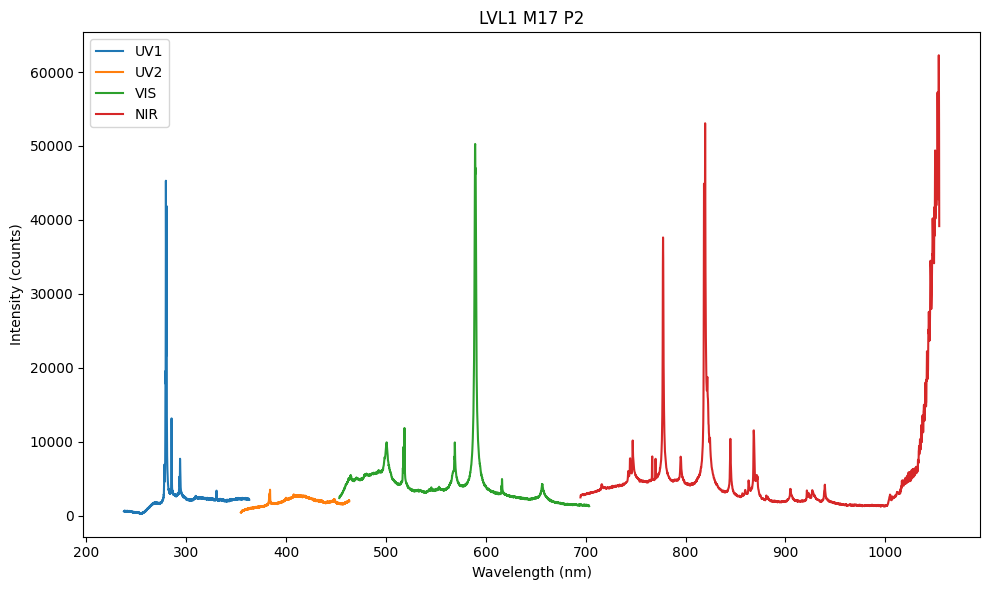

[OK] Saved Level1_M17_P2 to ..\Spectra\FinalSamples\Level1


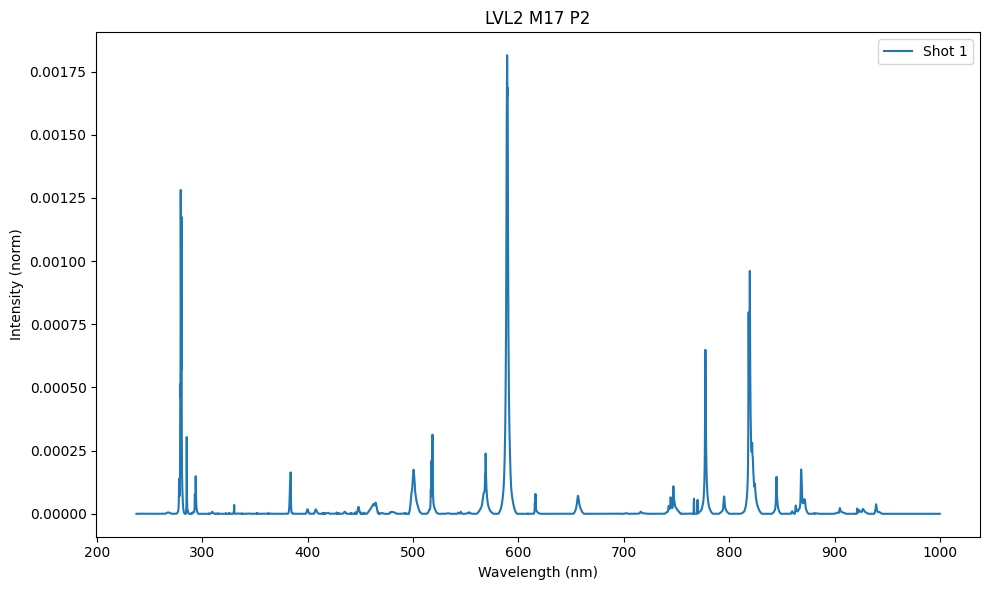

[OK] Saved Level2_M17_P2 to ..\Spectra\FinalSamples\Level2
M17_P3: utilizando 2 de 4 shots para el promedio


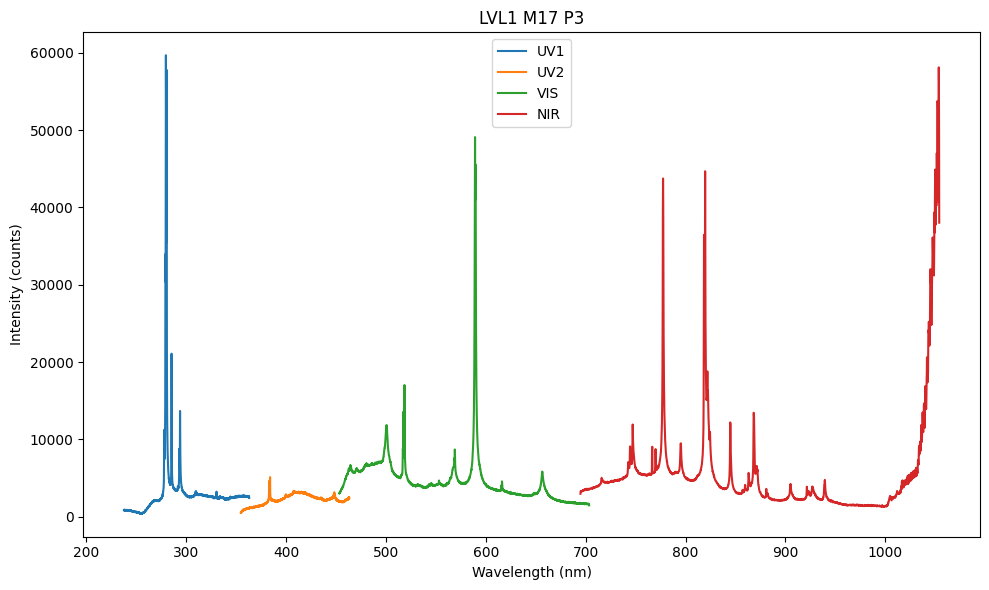

[OK] Saved Level1_M17_P3 to ..\Spectra\FinalSamples\Level1


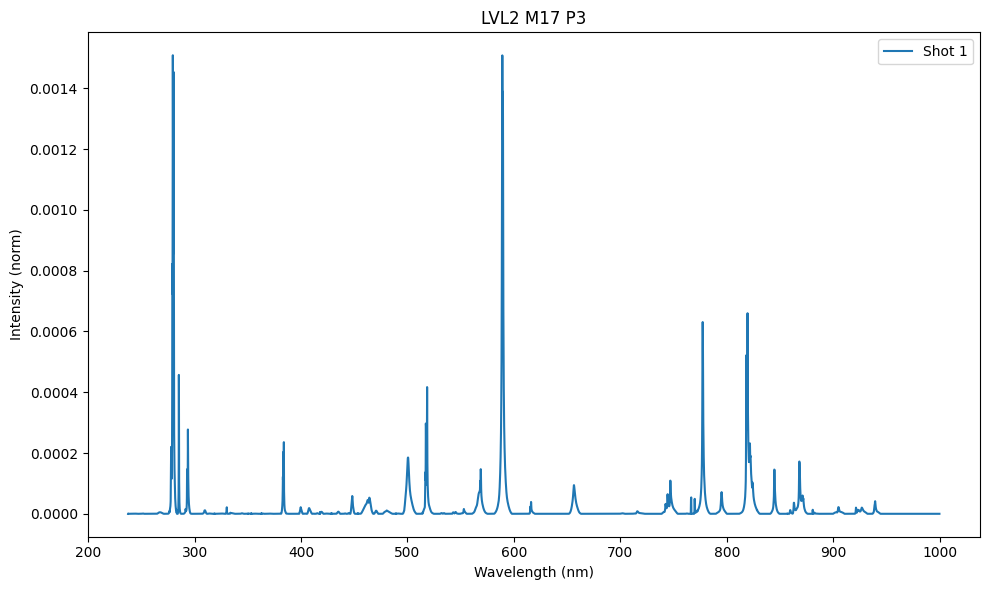

[OK] Saved Level2_M17_P3 to ..\Spectra\FinalSamples\Level2
M18_P1: utilizando 3 de 4 shots para el promedio


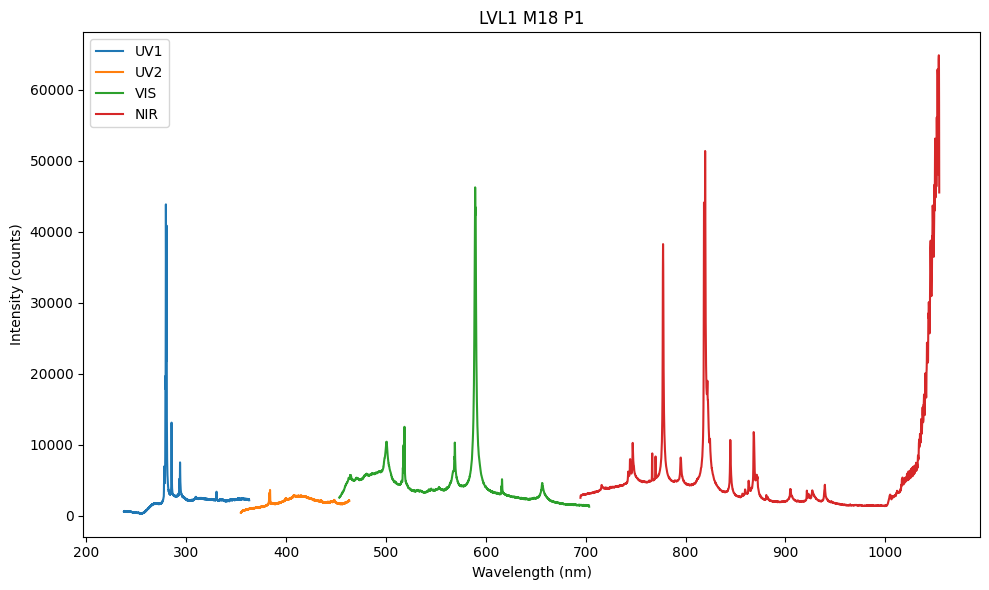

[OK] Saved Level1_M18_P1 to ..\Spectra\FinalSamples\Level1


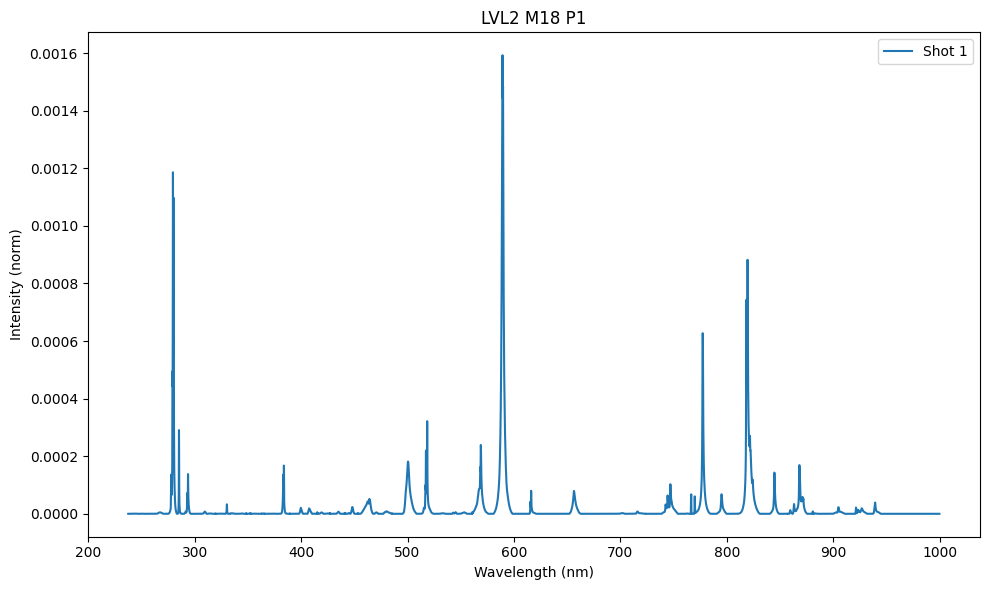

[OK] Saved Level2_M18_P1 to ..\Spectra\FinalSamples\Level2
M18_P2: utilizando 4 de 4 shots para el promedio


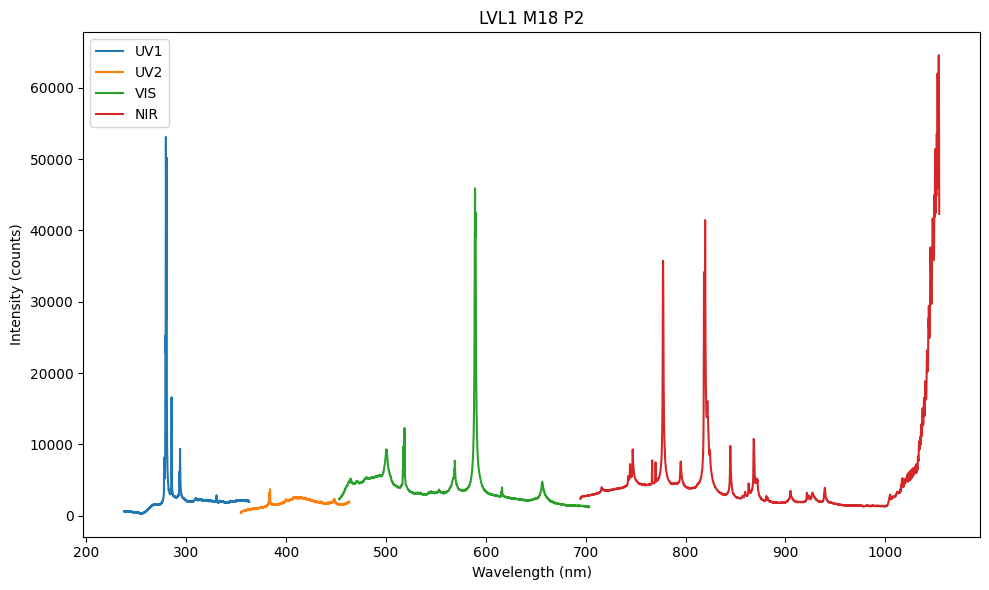

[OK] Saved Level1_M18_P2 to ..\Spectra\FinalSamples\Level1


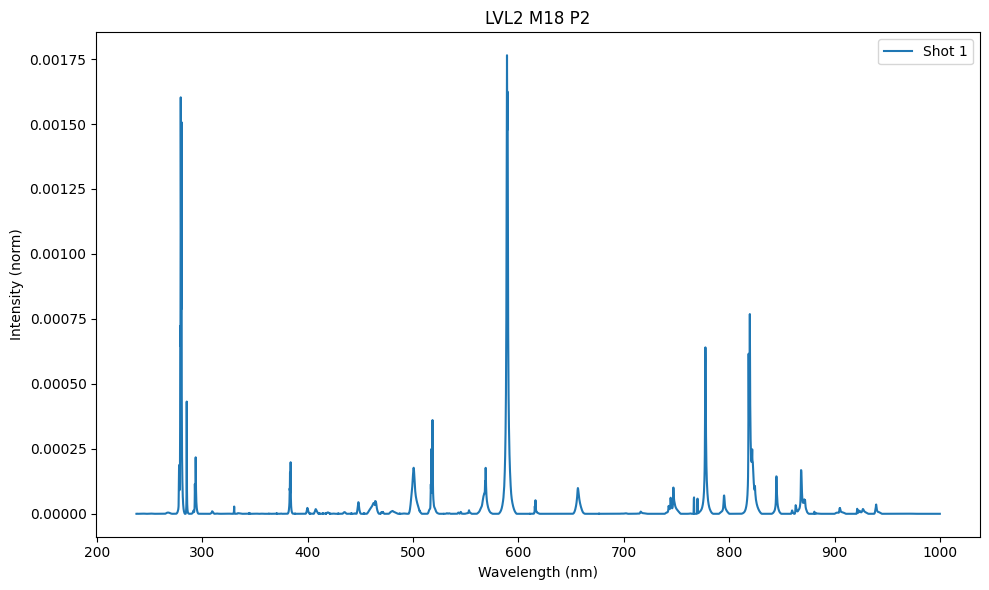

[OK] Saved Level2_M18_P2 to ..\Spectra\FinalSamples\Level2
M18_P3: utilizando 3 de 4 shots para el promedio


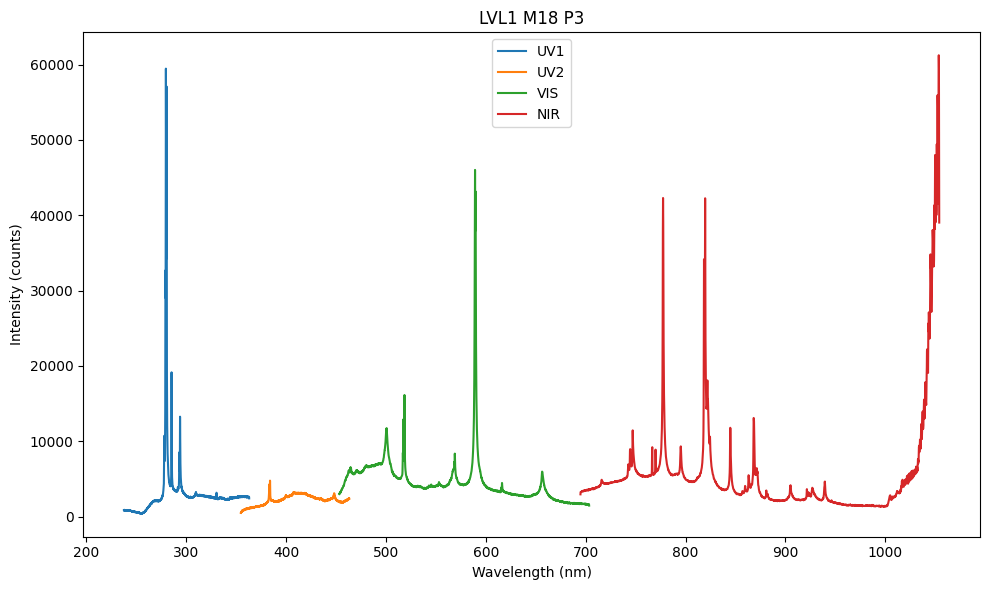

[OK] Saved Level1_M18_P3 to ..\Spectra\FinalSamples\Level1


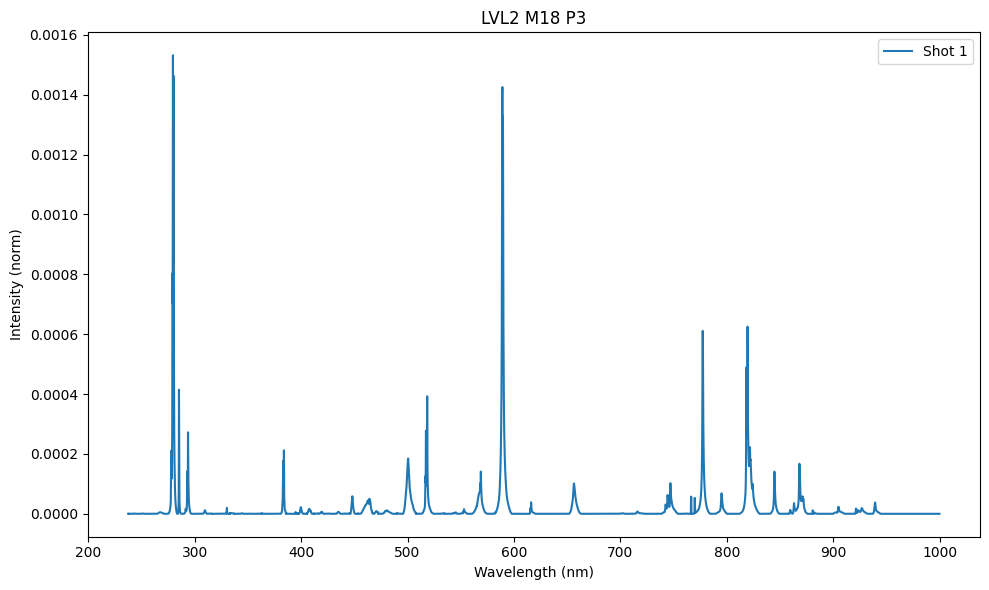

[OK] Saved Level2_M18_P3 to ..\Spectra\FinalSamples\Level2
M19_P1: utilizando 3 de 4 shots para el promedio


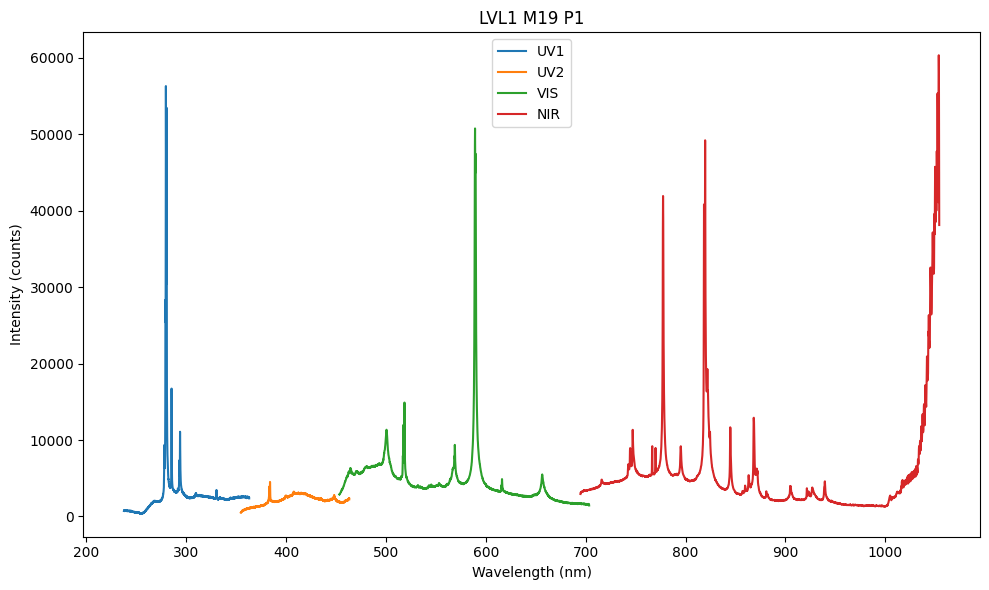

[OK] Saved Level1_M19_P1 to ..\Spectra\FinalSamples\Level1


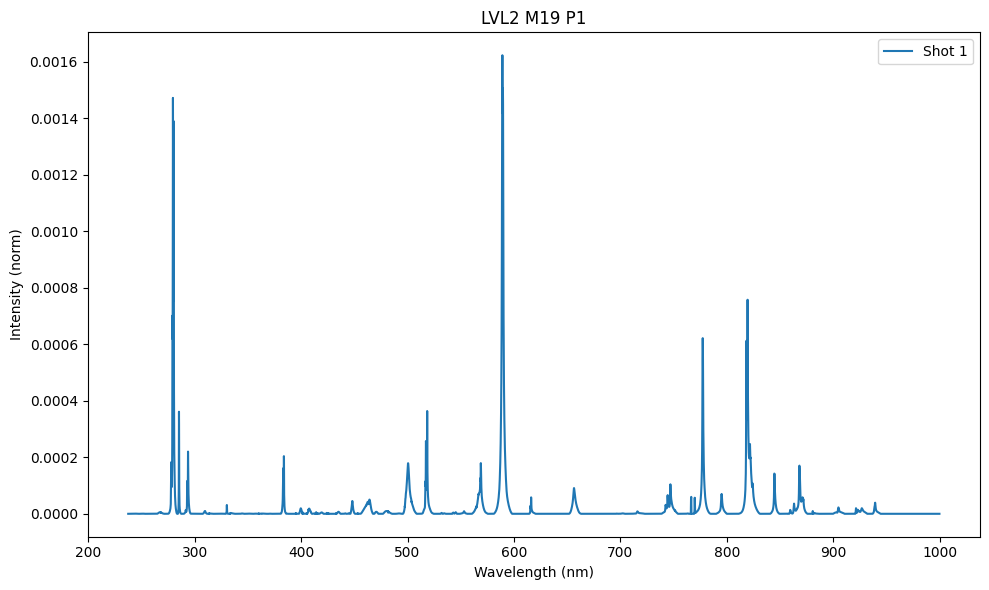

[OK] Saved Level2_M19_P1 to ..\Spectra\FinalSamples\Level2
M19_P2: utilizando 2 de 4 shots para el promedio


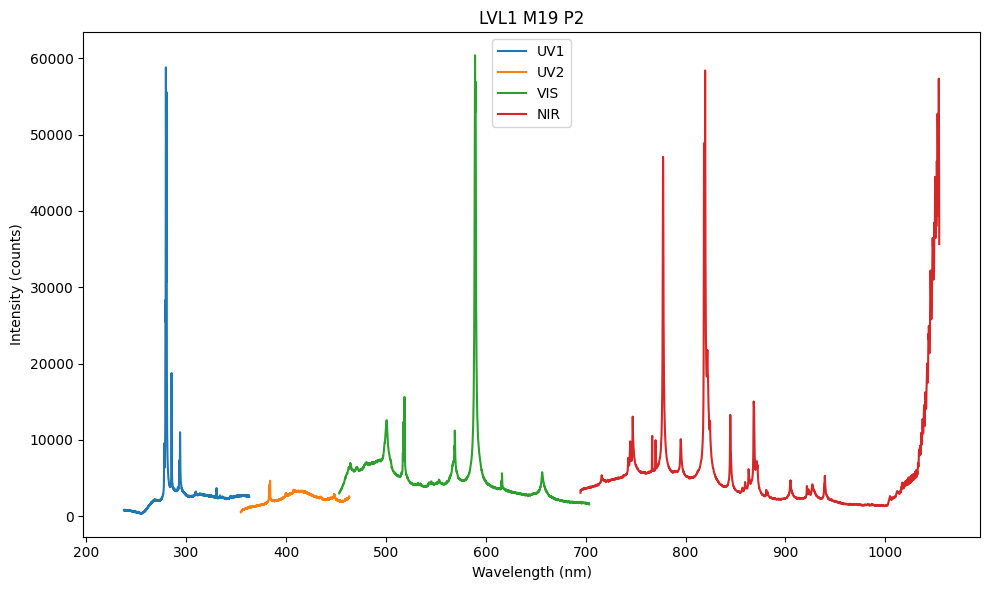

[OK] Saved Level1_M19_P2 to ..\Spectra\FinalSamples\Level1


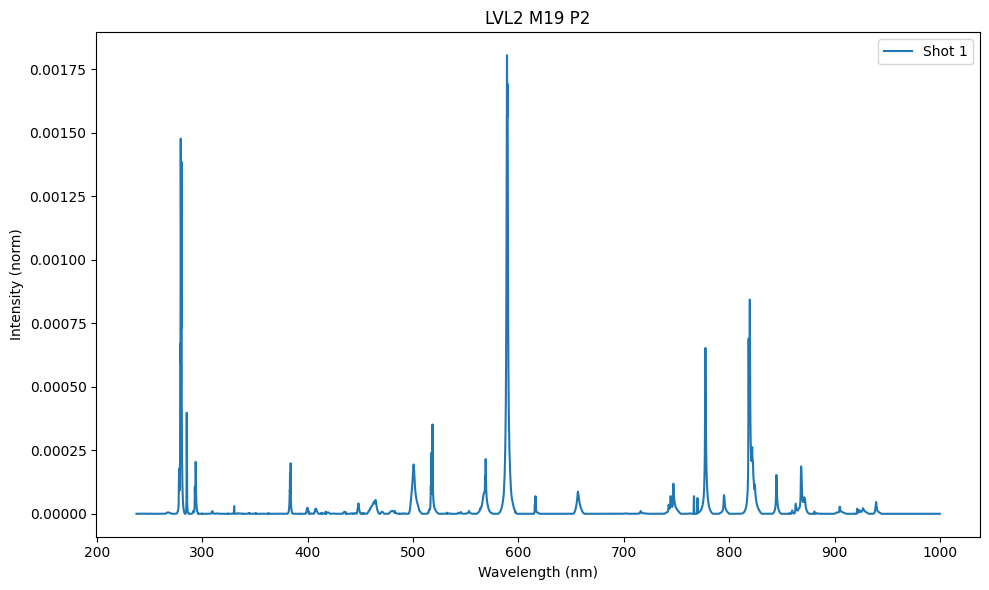

[OK] Saved Level2_M19_P2 to ..\Spectra\FinalSamples\Level2
M19_P3: utilizando 1 de 4 shots para el promedio


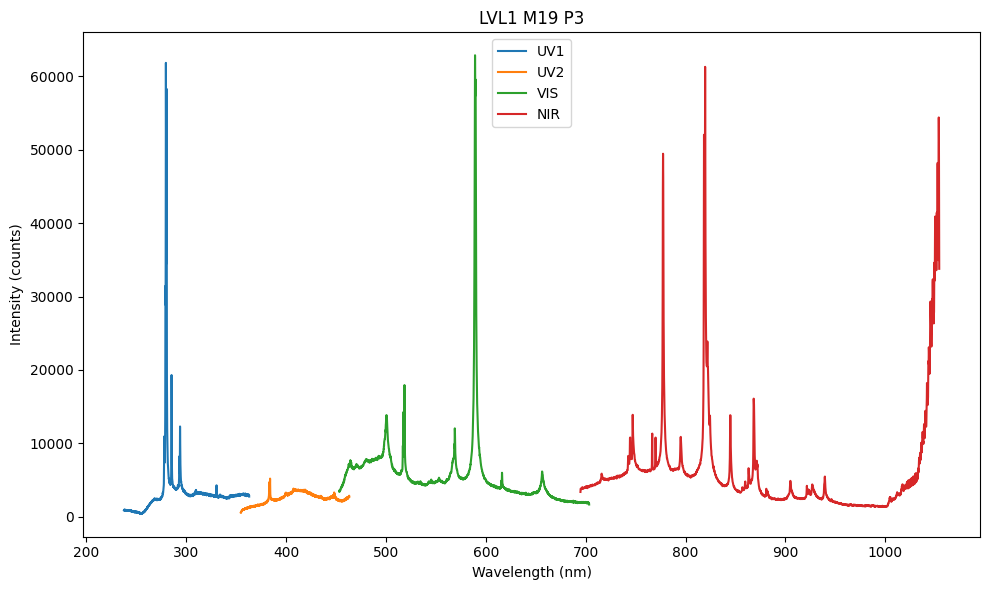

[OK] Saved Level1_M19_P3 to ..\Spectra\FinalSamples\Level1


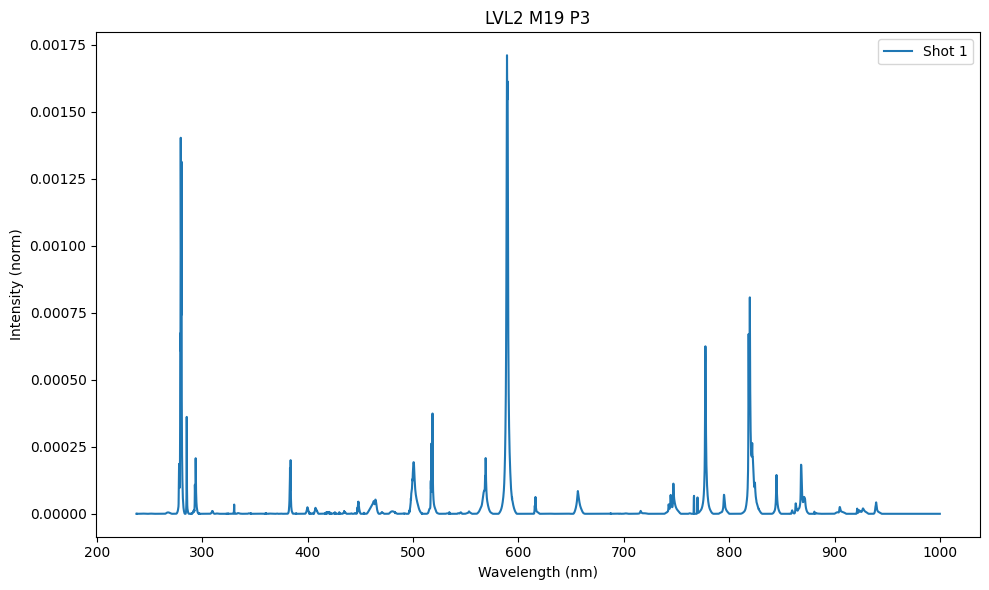

[OK] Saved Level2_M19_P3 to ..\Spectra\FinalSamples\Level2
Error al leer el Dark: [Errno 2] No such file or directory: '..\\Spectra\\FinalSamples\\Level0\\M2\\P1\\M2_P1_shot1_UV1.txt'


FileNotFoundError: No se pudo leer dark en ..\Spectra\FinalSamples\Level0\M2\P1\M2_P1_shot1_UV1.txt

In [10]:
lvl0_to_lvl1('FinalSamples')